# Understanding the Variability and Model Dependence of Lunar Regolith Properties

- Carlos Gómez de Olea Ballester
- Visiting Researcher at the Miyamoto Laboratory, Department of Systems Innovation, The University of Tokyo
- July 2026

## Imports

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

from Regolith1D_JGR import (
    rho_effective_carlos_new2, 
    porosity, 
    pore_filling_fraction, 
    get_Cr,
    cp_dry_Hayne_2017,
    cp_ice_Shulman_2004,
    k_eff,
    k_eff_Mellon_1997_new,
    K_Hayne_2017,
    K_phonon_cond,
    k_ice_Hobbs_1974,
    cp_effective_carlos,
    Grid1D)

from RadiativeTransfer import (
    loss_tangent_carrier_1991, 
    loss_tangent_feng_2020, 
    loss_tangent_feng_2021_highland,
    loss_tangent_feng_2021_mare,
    dielectric_constant_LLL,
    dielectric_constant_regolith,
    dielectric_constant_CS,
    dielectric_constant_GM,
    dielectric_constant_regolith_icy_new,
    compute_absorption_coefficient
)

from Regolith1D_JGR import (
    albedo_hayne_2017,
    albedo_yu_2025_highland,
    albedo_yu_2025_mare,
    albedo_vasavada_mare_2012,
    albedo_vasavada_highland_2012,
    albedo_feng_2020_mare,
    albedo_feng_2020_highland,
    cos_iota)

import seaborn as sns


## Define Parameter Space

In [ ]:
# Settings
Nz = 200         # number of depth layers
Nmc = 10_000     # Number of parameter samples per depth layer


# Temperatures for dry case (LAT = 0-80º approx)
T_deep_vec = np.random.uniform(110, 260, Nmc) # Ensure I have the same seed for all plots

def get_T_dry(depth, T_deep_vec, z_change = 0.2):
    
    # Sample temperature at acretain depth
    
    # From z_change, temperatures profiles are stationary
    T_min_deep = 110 # Approx deep temperature at LAT = 80º
    T_max_deep = 260 # Approx deep temperature at LAT = 0º

    if depth >= z_change:
        return T_deep_vec  # EXACT same vector

    T_min_surf = 50 # Conservative min surface temperature (LAT = 80º)
    T_max_surf = 400 # Conservative max surface temperature (LAT = 0º)

    alpha = depth / z_change

    T_min = T_min_surf + (T_min_deep - T_min_surf) * alpha
    T_max = T_max_surf + (T_max_deep - T_max_surf) * alpha

    T_scaled = (T_deep_vec - T_min_deep) / (T_max_deep - T_min_deep)
    return T_min + T_scaled * (T_max - T_min)
        
# Icy temperature ranges.
T_icy = np.random.uniform(25, 160, Nmc)

# Depth grid
z_vals = np.linspace(0, 0.5, Nz)



###################################### 
####.      MODEL PARAMETERS       #### 
#### See manuscript for reference #### 
###################################### 

# STRUCTURAL PARAMETERS (DRY)
rho_s = np.random.uniform(1100, 1300, Nmc)
rho_d = np.random.uniform(1600, 1900, Nmc)

# STRUCTURAL PARAMETERS (ICY)
wt_max = np.random.uniform(0, 10, Nmc)
z_start = np.random.uniform(0.005, 0.05, Nmc)
z_end = np.random.uniform(0.15, 5, Nmc)
dz = np.random.uniform(0.005, 0.05, Nmc)
rho_basalt = np.random.uniform(2750, 3500, Nmc)

# CONDUCTIVE PARAMETERS
Kd = np.random.uniform(3e-3, 7e-3, Nmc)
Ks = np.random.uniform(5e-4, 2e-3, Nmc)
Chi = np.random.uniform(2, 3, Nmc)
k_solid = np.random.uniform(1.0, 4.0, Nmc)

## Variability of TiO2 (mare) -> Giguere et al. 2000

In [ ]:
# Counts from your dataset
counts = np.array([
    1, 2, 4, 6, 14, 18, 5, 3, 3, 5, 6, 1, 1, 0,
    1, 1, 1, 0, 1, 3, 4, 2, 3, 8, 6, 7, 2, 0
])

# Normalize to probabilities
prob = counts / counts.sum()

# Bin edges (0 → 14 wt%, step 0.5)
bin_edges = np.arange(0, 14.5, 0.5)  # length = 29
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def sample_tio2(Nmc):
    # Step 1: choose bins
    bin_indices = np.random.choice(len(counts), size=Nmc, p=prob)
    
    # Step 2: sample uniformly within each bin
    lower = bin_edges[bin_indices]
    upper = bin_edges[bin_indices + 1]
    
    S_tiO2 = np.random.uniform(lower, upper)
    
    return S_tiO2

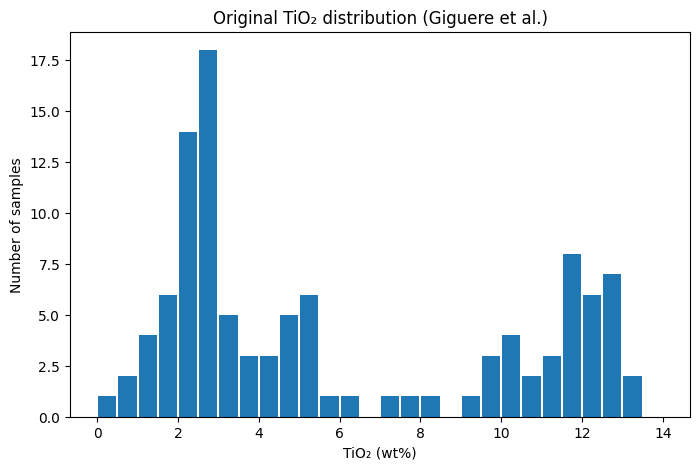

In [4]:
plt.figure(figsize=(8,5))
plt.bar(bin_centers, counts, width=0.45)
plt.xlabel("TiO₂ (wt%)")
plt.ylabel("Number of samples")
plt.title("Original TiO₂ distribution (Giguere et al.)")
plt.show()

## Variability range for H parameter

### PDF function computed by Hayne et al. (2017) from Diviner data.
We used the plotdigitizer.com digital app to extract the points from Figure 9.

In [5]:
data = np.array([
[0.000, 0.0002], [0.005, 0.0002], [0.010, 0.0003], [0.014, 0.0004], [0.019, 0.0006],
[0.024, 0.0009], [0.028, 0.0013], [0.032, 0.0019], [0.037, 0.0031], [0.041, 0.0051],
[0.045, 0.0084], [0.047, 0.0128], [0.051, 0.0231], [0.054, 0.0441], [0.056, 0.0806],
[0.059, 0.1439], [0.061, 0.2487], [0.063, 0.4318], [0.066, 0.6523], [0.068, 0.7782],
[0.070, 0.7791], [0.071, 0.7044], [0.072, 0.5716], [0.073, 0.4608], [0.075, 0.3194],
[0.076, 0.2073], [0.077, 0.1323], [0.079, 0.0805], [0.080, 0.0479], [0.081, 0.0276],
[0.083, 0.0163], [0.085, 0.0097], [0.087, 0.0055], [0.089, 0.0034], [0.091, 0.0021],
[0.094, 0.0014], [0.097, 0.0011], [0.100, 0.0008], [0.102, 0.0007], [0.105, 0.0005],
[0.108, 0.0004], [0.111, 0.0003], [0.113, 0.0003], [0.116, 0.0002], [0.119, 0.0002],
[0.122, 0.0002], [0.126, 0.0001], [0.135, 0.00008], [0.142, 0.00006], [0.150, 0.00006]
])


H = data[:,0]
P = data[:,1]

In [6]:
# smooth interpolation of PDF
pdf_interp = interp1d(H, P, kind='cubic', fill_value=0, bounds_error=False)

# fine grid
x_fine = np.linspace(H.min(), H.max(), 2000)
pdf_fine = pdf_interp(x_fine)

# remove negatives (cubic can overshoot)
pdf_fine = np.clip(pdf_fine, 0, None)

# normalize PDF
pdf_fine /= np.trapz(pdf_fine, x_fine)

# build CDF
cdf = cumulative_trapezoid(pdf_fine, x_fine, initial=0)
cdf /= cdf[-1]

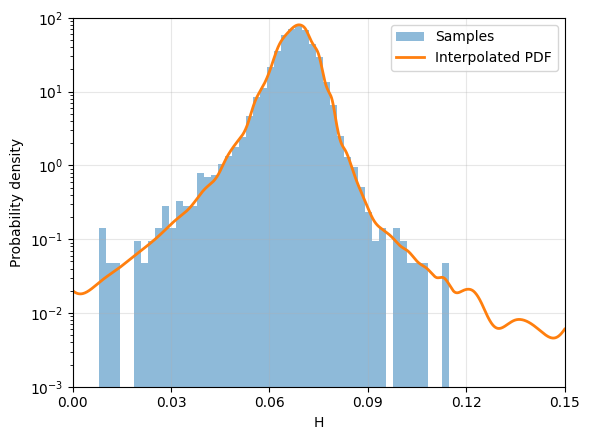

In [7]:
N = Nmc

# inverse transform sampling
u = np.random.rand(N)

samples = np.interp(u, cdf, x_fine)

plt.figure(figsize=(6,4.5))

# histogram of samples
plt.hist(samples, bins=50, density=True, alpha=0.5, label="Samples")

# original + interpolated PDF
plt.plot(x_fine, pdf_fine, linewidth=2, label="Interpolated PDF")

plt.xlabel("H")
plt.ylabel("Probability density")
plt.xticks(np.arange(0,0.16, 0.03))
plt.xlim([0, 0.15])
plt.ylim([1e-3, 1e2])

plt.yscale("log")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Superimposed H distribution with Figure 9 from Hayne et al. 2017

<img src='/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/FIGS/Hayne_superimposed.png' width="500">

In [8]:
# x = H values, p = probability weights
x = np.round(data[:,0], 3)
p = np.round(data[:,1], 4)

# Create continuous PDF interpolation
pdf_interp = interp1d(
    x,
    p,
    kind="cubic",
    bounds_error=False,
    fill_value=0
)

# Fine grid for continuous distribution
x_fine = np.linspace(
    x.min(),
    x.max(),
    10000
)

pdf = pdf_interp(x_fine)

# Avoid negative interpolation artefacts
pdf[pdf < 0] = 0

# Normalize PDF
pdf /= np.trapz(pdf, x_fine)

# Construct CDF
cdf = np.cumsum(pdf)
cdf /= cdf[-1]

# Sample N values
N = 10_000

random_values = np.random.rand(N)

H = np.interp(
    random_values,
    cdf,
    x_fine
)

### Destination folder for figures
Modify at will

In [ ]:
current_dir = os.getcwd()
root_folder = os.path.join(current_dir, "FIGS") # Store figures here

### Colormap

In [11]:
colors = [
    '#E69F00', '#56B4E9', '#009E73', '#D55E00', 
    '#0072B2', '#F0E442' , '#CC79A7', '#000000',
    '#88DDCC', '#777777', '#882255', '#999933' 
]

## Statistical Correlations and other analysis

### Density

In [11]:
# ==========================================================
# DRY REGOLITH CORRELATION
# ==========================================================

corr_H_dry = []
corr_rho_s_dry = []
corr_rho_d_dry = []


for z in z_vals:

    # Density model
    rho = rho_effective_carlos_new2(np.full(Nmc, z), H = H, rho_s = rho_s, rho_d = rho_d)

    df = pd.DataFrame({
        "H": H,
        "rho_s": rho_s,
        "rho_d": rho_d,
        "rho": rho
    })


    corr = df.corr(method="spearman")


    corr_H_dry.append(
        corr.loc["rho", "H"]
    )

    corr_rho_s_dry.append(
        corr.loc["rho", "rho_s"]
    )

    corr_rho_d_dry.append(
        corr.loc["rho", "rho_d"]
    )


corr_H_dry = np.array(corr_H_dry)
corr_rho_s_dry = np.array(corr_rho_s_dry)
corr_rho_d_dry = np.array(corr_rho_d_dry)



# ==========================================================
# ICY REGOLITH CORRELATION
# ==========================================================

corr_H_icy = []
corr_rho_s_icy = []
corr_rho_d_icy = []
corr_wt_max = []
corr_z_start = []
corr_z_end = []
corr_delta = []


for z in z_vals:

    # Evaluate density model
    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )

    df = pd.DataFrame({

        "H": H,
        "rho_s": rho_s,
        "rho_d": rho_d,
        "wt_max": wt_max,
        "z_start": z_start,
        "z_end": z_end,
        "delta": dz,
        "rho": rho

    })


    corr = df.corr(
        method="spearman"
    )


    corr_H_icy.append(
        corr.loc["rho","H"]
    )

    corr_rho_s_icy.append(
        corr.loc["rho","rho_s"]
    )

    corr_rho_d_icy.append(
        corr.loc["rho","rho_d"]
    )

    corr_wt_max.append(
        corr.loc["rho","wt_max"]
    )

    corr_z_start.append(
        corr.loc["rho","z_start"]
    )

    corr_z_end.append(
        corr.loc["rho","z_end"]
    )

    corr_delta.append(
        corr.loc["rho","delta"]
    )



corr_H_icy = np.array(corr_H_icy)
corr_rho_s_icy = np.array(corr_rho_s_icy)
corr_rho_d_icy = np.array(corr_rho_d_icy)
corr_wt_max = np.array(corr_wt_max)
corr_z_start = np.array(corr_z_start)
corr_z_end = np.array(corr_z_end)
corr_delta = np.array(corr_delta)

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


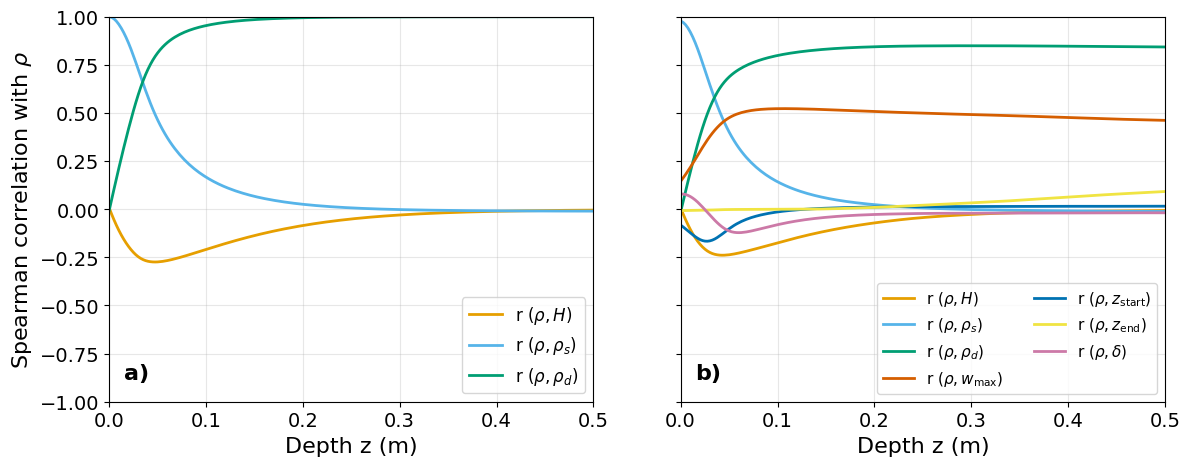

In [12]:
# ==========================================================
# FINAL COMBINED FIGURE
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5),
    sharey=True
)


plt.subplots_adjust(
    wspace=0.18,
    left=0.10,
    right=0.98,
    bottom=0.18,
    top=0.95
)


# ----------------------------------------------------------
# (a) DRY
# ----------------------------------------------------------

axes[0].plot(
    z_vals,
    corr_H_dry,
    linewidth=2,
    color=colors[0],
    label=r"r $(\rho,H)$"
)

axes[0].plot(
    z_vals,
    corr_rho_s_dry,
    linewidth=2,
    color=colors[1],
    label=r"r $(\rho,\rho_s)$"
)

axes[0].plot(
    z_vals,
    corr_rho_d_dry,
    linewidth=2,
    color=colors[2],
    label=r"r $(\rho,\rho_d)$"
)


axes[0].set_xlabel(
    "Depth z (m)",
    fontsize=16
)

axes[0].set_ylabel(
    r"Spearman correlation with $\rho$",
    fontsize=16
)

axes[0].set_xlim(
    0,
    0.5
)

axes[0].set_ylim(
    -1,
    1
)

axes[0].set_yticks(
    np.linspace(-1,1,9)
)

axes[0].tick_params(
    labelsize=14
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend(
    fontsize=12,
    loc="lower right"
)


axes[0].text(
    0.03,
    0.1,
    "a)",
    transform=axes[0].transAxes,
    fontsize=16,
    fontweight="bold",
    color="black",
    va="top"
)



# ----------------------------------------------------------
# (b) ICY
# ----------------------------------------------------------

axes[1].plot(
    z_vals,
    corr_H_icy,
    linewidth=2,
    color=colors[0],
    label=r"r $(\rho,H)$"
)

axes[1].plot(
    z_vals,
    corr_rho_s_icy,
    linewidth=2,
    color=colors[1],
    label=r"r $(\rho,\rho_s)$"
)

axes[1].plot(
    z_vals,
    corr_rho_d_icy,
    linewidth=2,
    color=colors[2],
    label=r"r $(\rho,\rho_d)$"
)

axes[1].plot(
    z_vals,
    corr_wt_max,
    linewidth=2,
    color=colors[3],
    label=r"r $(\rho,w_{\mathrm{max}})$"
)

axes[1].plot(
    z_vals,
    corr_z_start,
    linewidth=2,
    color=colors[4],
    label=r"r $(\rho,z_{\mathrm{start}})$"
)

axes[1].plot(
    z_vals,
    corr_z_end,
    linewidth=2,
    color=colors[5],
    label=r"r $(\rho,z_{\mathrm{end}})$"
)

axes[1].plot(
    z_vals,
    corr_delta,
    linewidth=2,
    color=colors[6],
    label=r"r $(\rho,\delta)$"
)


axes[1].set_xlabel(
    "Depth z (m)",
    fontsize=16
)

axes[1].set_xlim(
    0,
    0.5
)

axes[1].set_ylim(
    -1,
    1
)

axes[1].tick_params(
    labelsize=14
)

axes[1].grid(
    alpha=0.3
)

axes[1].legend(
    fontsize=11,
    ncols=2,
    loc="lower right"
)


axes[1].text(
    0.03,
    0.1,
    "b)",
    transform=axes[1].transAxes,
    fontsize=16,
    fontweight="bold",
    color="black",
    va="top"
)



# ==========================================================
# SAVE
# ==========================================================

save_folder = os.path.join(
    root_folder,
    "Dry", "Density"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "correlation_dry_vs_icy.pdf"
    ),
    bbox_inches="tight"
)


plt.show()

### Porosity, Cr, PFF

In [15]:
corr_outputs = {

    "Cr": {
        "H": [], "rho_s": [], "rho_d": [],
        "wt_max": [], "z_start": [], "z_end": [],
        "dz": [], "rho_basalt": []
    },

    "phi": {
        "H": [], "rho_s": [], "rho_d": [],
        "wt_max": [], "z_start": [], "z_end": [],
        "dz": [], "rho_basalt": []
    },

    "PFF": {
        "H": [], "rho_s": [], "rho_d": [],
        "wt_max": [], "z_start": [], "z_end": [],
        "dz": [], "rho_basalt": []
    },

    "mult": {
        "H": [], "rho_s": [], "rho_d": [],
        "wt_max": [], "z_start": [], "z_end": [],
        "dz": [], "rho_basalt": []
    }

}


for z in z_vals:

    # -------------------------
    # Model
    # -------------------------

    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )


    Cr = get_Cr(
        rho,
        z,
        H=H,
        rho_s=rho_s,
        rho_d=rho_d
    )

    phi = porosity(
        rho,
        rho_basalt=rho_basalt
    )

    PFF = pore_filling_fraction(
        z,
        Cr,
        phi,
        H=H,
        rho_s=rho_s,
        rho_d=rho_d
    )

    mult = PFF * phi


    # -------------------------
    # Correlation dataframe
    # -------------------------

    df = pd.DataFrame({

        "H": H,
        "rho_s": rho_s,
        "rho_d": rho_d,
        "wt_max": wt_max,
        "z_start": z_start,
        "z_end": z_end,
        "dz": dz,
        "rho_basalt": rho_basalt,

        "Cr": Cr,
        "phi": phi,
        "PFF": PFF,
        "mult": mult

    })


    c = df.corr(
        method="spearman"
    )


    # -------------------------
    # Store correlations
    # -------------------------

    for output in ["Cr", "phi", "PFF", "mult"]:

        for param in corr_outputs[output].keys():

            corr_outputs[output][param].append(
                c.loc[output, param]
            )

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


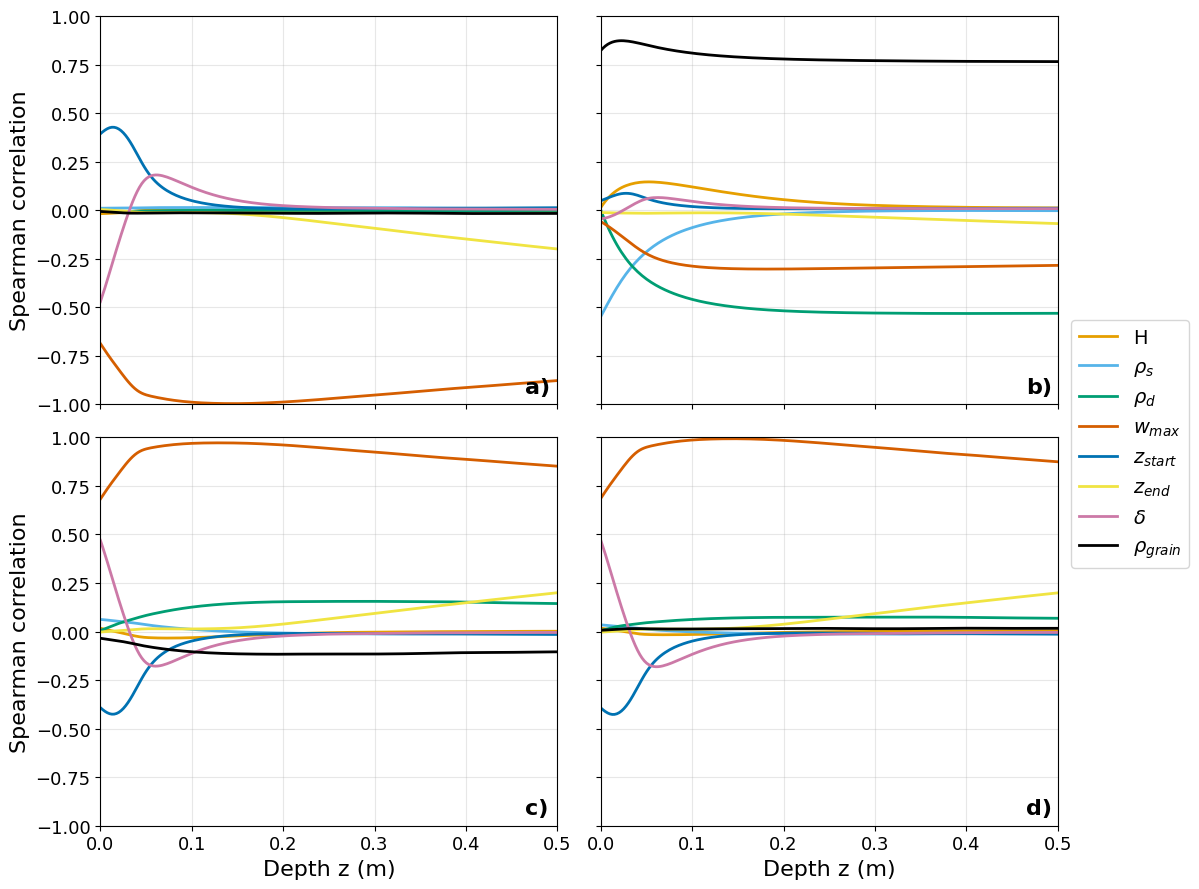

In [16]:
# ==========================================================
# PLOT 2x2 FIGURE
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

plt.subplots_adjust(
    right=0.84,
    wspace=0.15,
    hspace=0.15
)

plot_info = {

    "Cr": (
        r"$C_r$",
        "Compaction Ratio"
    ),

    "phi": (
        r"$\phi$",
        "Porosity"
    ),

    "PFF": (
        r"$F$",
        "Pore Filling Fraction"
    ),

    "mult": (
        r"$F\phi$",
        r"$F\phi$"
    )
}


for ax, (output, (name, long_name)) in zip(
    axes,
    plot_info.items()
):

    ax.plot(
        z_vals,
        corr_outputs[output]["H"],
        label=r"H".format(name),
        linewidth=2,
        color = colors[0]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["rho_s"],
        label=r"$\rho_s$".format(name),
        linewidth=2,
        color = colors[1]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["rho_d"],
        label=r"$\rho_d$".format(name),
        linewidth=2,
        color = colors[2]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["wt_max"],
        label=r"$w_{{max}}$".format(name),
        linewidth=2,
        color = colors[3]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["z_start"],
        label=r"$z_{{start}}$".format(name),
        linewidth=2,
        color = colors[4]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["z_end"],
        label=r"$z_{{end}}$".format(name),
        linewidth=2,
        color = colors[5]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["dz"],
        label=r"$\delta$".format(name),
        linewidth=2,
        color = colors[6]
    )

    ax.plot(
        z_vals,
        corr_outputs[output]["rho_basalt"],
        label=r"$\rho_{{grain}}$".format(name),
        linewidth=2,
        color = colors[7]
    )

    if ax in [0, 1]:
        xpos, ypos = 0.93, 0.93
    else:
        xpos, ypos = 0.93, 0.03

    ax.text(
        xpos,
        ypos,
        chr(97 + list(plot_info.keys()).index(output)) + ")",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        color="black"
    )

    ax.grid(
        alpha=0.3
    )

    ax.set_xlim(
        0,
        0.5
    )

    ax.set_ylim(
        -1,
        1
    )


for ax in axes[2:]:
    ax.set_xlabel(
        "Depth z (m)",
        fontsize=16
    )

for ax in axes[::2]:
    ax.set_ylabel(
        "Spearman correlation",
        fontsize=16
    )


for ax in axes:
    ax.tick_params(
        labelsize=13
    )

    ax.set_yticks(
        np.linspace(-1,1,9)
    )


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.82, 0.5),
    fontsize=14,
    frameon=True,
    ncols=1
)

plt.tight_layout(rect=[0, 0, 0.84, 1])


# ==========================================================
# SAVE
# ==========================================================

save_folder = os.path.join(
    root_folder,
    "Icy",
    "Structure"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "correlation_all_outputs.pdf"
    ),
    bbox_inches="tight"
)


plt.show()

## Thermal properties

### Heat Capacity

In [ ]:
rho_ice = 918.0

S_T = np.zeros(Nz)   # thermal importance
S_a = np.zeros(Nz)   # structural importance

cp_mean = np.zeros(Nz)
a_mean = np.zeros(Nz)

a_min_global = np.inf
a_max_global = -np.inf

# -------------------------
# MAIN LOOP OVER DEPTH
# -------------------------
for iz, z in enumerate(z_vals):
    
    T_min = 25
    T_max = 160

    T = T_icy

    # -------------------------
    # density model
    # -------------------------
    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )

    # -------------------------
    # structural properties
    # -------------------------
    Cr = get_Cr(rho, z, H=H, rho_s=rho_s, rho_d=rho_d)
    phi = porosity(rho, rho_basalt=rho_basalt)
    PFF = pore_filling_fraction(z, Cr, phi, H=H, rho_s=rho_s, rho_d=rho_d)

    # -------------------------
    # structural factor a(z)
    # -------------------------
    a = phi * PFF * (rho_ice / rho)

    # -------------------------
    # UPDATE GLOBAL MIN/MAX OF a
    # -------------------------
    a_min_global = min(a_min_global, np.min(a))
    a_max_global = max(a_max_global, np.max(a))

    # -------------------------
    # heat capacity model
    # -------------------------
    cp_dry = cp_dry_Hayne_2017(T)
    cp_ice = cp_ice_Shulman_2004(T)

    cp = cp_dry + a * cp_ice

    # =====================================================
    # VARIANCE DECOMPOSITION
    # =====================================================

    # thermal-only effect (freeze a)
    a_bar = np.mean(a)
    cp_T_only = cp_dry + a_bar * cp_ice
    Var_T = np.var(cp_T_only)

    # structural-only effect (freeze T)
    cp_a_only = np.mean(cp_dry) + a * np.mean(cp_ice)
    Var_a = np.var(cp_a_only)

    # normalize importance
    denom = Var_T + Var_a + 1e-12
    S_T[iz] = Var_T / denom
    S_a[iz] = Var_a / denom

    # store diagnostics
    cp_mean[iz] = np.mean(cp)
    a_mean[iz] = np.mean(a)

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# STORAGE FOR GLOBAL MANIFOLD
# -------------------------
T_all = []
a_all = []
cp_all = []

# -------------------------
# LOOP
# -------------------------
for iz, z in enumerate(z_vals):

    T = np.random.uniform(T_min, T_max, Nmc)

    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )

    Cr = get_Cr(rho, z, H=H, rho_s=rho_s, rho_d=rho_d)
    phi = porosity(rho, rho_basalt=rho_basalt)
    PFF = pore_filling_fraction(z, Cr, phi, H=H, rho_s=rho_s, rho_d=rho_d)

    a = phi * PFF * (917.0 / rho)

    cp = cp_dry_Hayne_2017(T) + a * cp_ice_Shulman_2004(T)

    T_all.append(T)
    a_all.append(a)
    cp_all.append(cp)

T_all = np.concatenate(T_all)
a_all = np.concatenate(a_all)
cp_all = np.concatenate(cp_all)

# -------------------------
# BINNING FOR COLORMAP
# -------------------------
nbins = 80

T_bins = np.linspace(T_all.min(), T_all.max(), nbins)
a_bins = np.linspace(a_all.min(), a_all.max(), nbins)

cp_grid = np.zeros((nbins - 1, nbins - 1))

# compute mean cp in each bin
for i in range(nbins - 1):
    for j in range(nbins - 1):

        mask = (
            (T_all >= T_bins[i]) & (T_all < T_bins[i+1]) &
            (a_all >= a_bins[j]) & (a_all < a_bins[j+1])
        )

        if np.any(mask):
            cp_grid[j, i] = np.mean(cp_all[mask])
        else:
            cp_grid[j, i] = np.nan


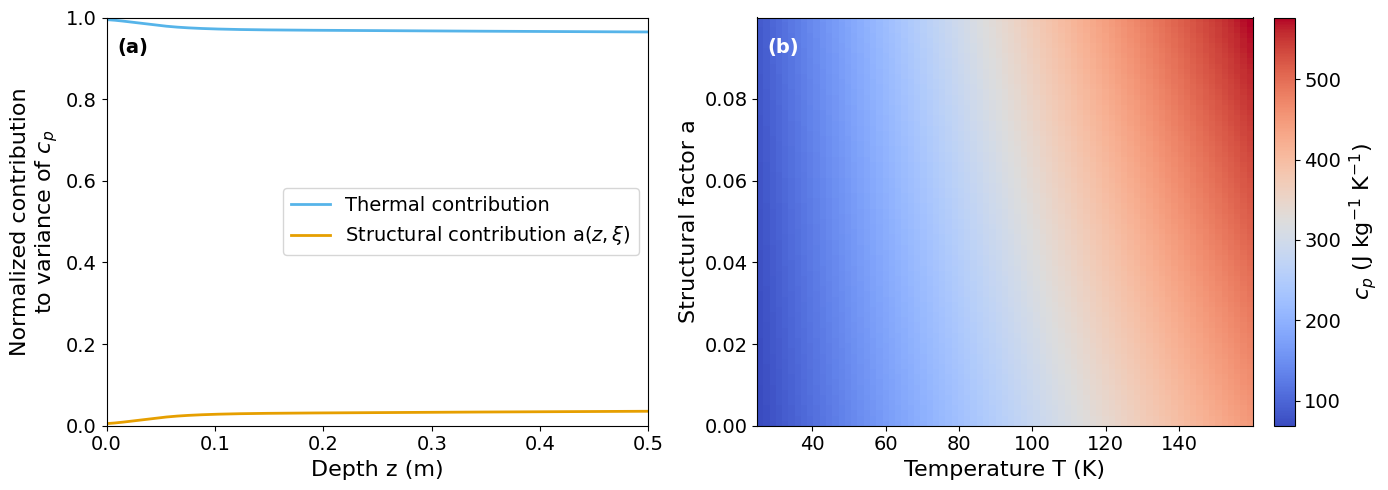

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================
# (a) VARIANCE CONTRIBUTIONS
# ======================================
ax = axes[0]

ax.plot(z_vals, S_T, label="Thermal contribution", linewidth=2, color = colors[1])
ax.plot(z_vals, S_a, label=r"Structural contribution a$(z, \xi)$", linewidth=2, color = colors[0])

ax.set_xlabel("Depth z (m)", fontsize=16)
ax.set_ylabel("Normalized contribution\nto variance of $c_p$", fontsize=16)
ax.set_xlim([0, 0.5])
ax.set_ylim([0, 1])

ax.tick_params(labelsize=14)
ax.legend(fontsize=14)

ax.text(
    0.02, 0.95, "(a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
    color="black"
)

# ======================================
# (b) CP MANIFOLD
# ======================================
ax = axes[1]

im = ax.imshow(
    cp_grid,
    origin="lower",
    aspect="auto",
    extent=[T_all.min(), T_all.max(), a_all.min(), a_all.max()],
    cmap="coolwarm"
)

ax.set_xlabel("Temperature T (K)", fontsize=16)
ax.set_ylabel("Structural factor a", fontsize=16)
ax.tick_params(labelsize=14)

ax.text(
    0.02, 0.95, "(b)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
    color="white"
)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$c_p$ (J kg$^{-1}$ K$^{-1}$)", size=16)
cbar.ax.tick_params(labelsize=14)

# ======================================
# FINAL LAYOUT
# ======================================
plt.tight_layout()

save_folder = os.path.join(root_folder, "Icy", "cp")
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "cp_combined_variance.pdf"))

plt.show()

### Conductivity - dry regolith

In [ ]:
corr_H = []
corr_Kd = []
corr_Ks = []
corr_Chi = []

# -------------------------
# LOOP OVER DEPTH
# -------------------------

for z in z_vals:
    
    T = get_T_dry(z, T_deep_vec)
    
    # -------------------------
    # Thermal factor
    # -------------------------
    K_dry = K_Hayne_2017(T, np.full(Nmc, z), H=H, Kd=Kd, Ks=Ks, Chi=Chi)

    # -------------------------
    # Correlation analysis
    # -------------------------
    df = pd.DataFrame({
        'H': H,
        'Kd': Kd,
        'Ks': Ks,
        'Chi': Chi,
        'K': K_dry
    })

    corr = df.corr(method="spearman")

    corr_H.append(corr.loc['K', 'H'])
    corr_Kd.append(corr.loc['K', 'Kd'])
    corr_Ks.append(corr.loc['K', 'Ks'])
    corr_Chi.append(corr.loc['K', 'Chi'])

corr_H = np.array(corr_H)
corr_Kd = np.array(corr_Kd)
corr_Ks = np.array(corr_Ks)
corr_Chi = np.array(corr_Chi)

'plt.figure(figsize=(7,5))\n\nplt.plot(z_vals, corr_H, label=r\'r ($K_{dry}$, H)\', linewidth=2, color = colors[0])\nplt.plot(z_vals, corr_Kd, label=r\'r ($K_{dry}$, $k_d$)\', linewidth=2, color = colors[1])\nplt.plot(z_vals, corr_Ks, label=r\'r ($K_{dry}$, $k_s$)\', linewidth=2, color = colors[2])\nplt.plot(z_vals, corr_Chi, label=r\'r ($K_{dry}$, $\\chi$)\', linewidth=2, color = colors[3])\n\nplt.xlabel("Depth z (m)", fontsize=16)\nplt.ylabel("Spearman Correlation with $K_{dry}$", fontsize=16)\nplt.ylim(-1,1)\nplt.xlim([0, 0.5])\nplt.xticks(fontsize = 14)\nplt.yticks(fontsize = 14)\n\n\nplt.grid(alpha=0.3)\nplt.legend(fontsize = 14, loc = "lower right", ncol = 2)\nplt.tight_layout()\nplt.savefig(os.path.join(save_folder, "correlation_plot.pdf"))\n\nplt.show()'

#### Variance decomposition

In [ ]:
S_T = np.zeros(Nz)
S_a = np.zeros(Nz)

K_mean = np.zeros(Nz)
Kph_mean = np.zeros(Nz)

# -------------------------
# MAIN LOOP
# -------------------------
for iz, z in enumerate(z_vals):

    T = get_T_dry(z, T_deep_vec)

    # -------------------------
    # Conductivity components
    # -------------------------
    Kph, _ = K_phonon_cond(np.full(Nmc, z), H, Kd, Ks, Chi)

    # thermal factor
    G = 1 + Chi * (T / 350.0) ** 3

    # total conductivity
    K = Kph * G

    # -------------------------
    # VARIANCE DECOMPOSITION
    # -------------------------

    # --- Thermal-only (freeze structure)
    Kph_bar = np.mean(Kph)
    K_T_only = Kph_bar * G
    Var_T = np.var(K_T_only)

    # --- Structural-only (freeze temperature)
    G_bar = np.mean(G)
    K_a_only = Kph * G_bar
    Var_a = np.var(K_a_only)

    # --- Normalize contributions
    denom = Var_T + Var_a
    S_T[iz] = Var_T / denom
    S_a[iz] = Var_a / denom

    # -------------------------
    # Diagnostics
    # -------------------------
    K_mean[iz] = np.mean(K)
    Kph_mean[iz] = Kph_bar

'# -------------------------\n# PLOT RESULTS\n# -------------------------\nplt.figure(figsize=(7, 5))\n\nplt.plot(z_vals, S_T, label=r"Thermal contribution ($\\Gamma$)", linewidth=2, color = colors[1])\nplt.plot(z_vals, S_a, label=r"Structural contribution ($K_c$)", linewidth=2, color = colors[0])\n\nplt.xlabel("Depth z (m)", fontsize=16)\nplt.ylabel("Normalized contribution\nto variance of K", fontsize=16)\nplt.xticks(fontsize = 14)\nplt.yticks(fontsize = 14)\nplt.xlim([0, 0.5])\nplt.ylim([0, 1])\n\nplt.grid(alpha=0.3)\nplt.legend(fontsize = 14)\n\nplt.tight_layout()\n\n# -------------------------\n# SAVE\n# -------------------------\nsave_folder = os.path.join(root_folder, "Dry", "k")\nos.makedirs(save_folder, exist_ok=True)\n\nplt.savefig(os.path.join(save_folder, "variance_k_contributions.pdf"))\n\nplt.show()'

#### Plot

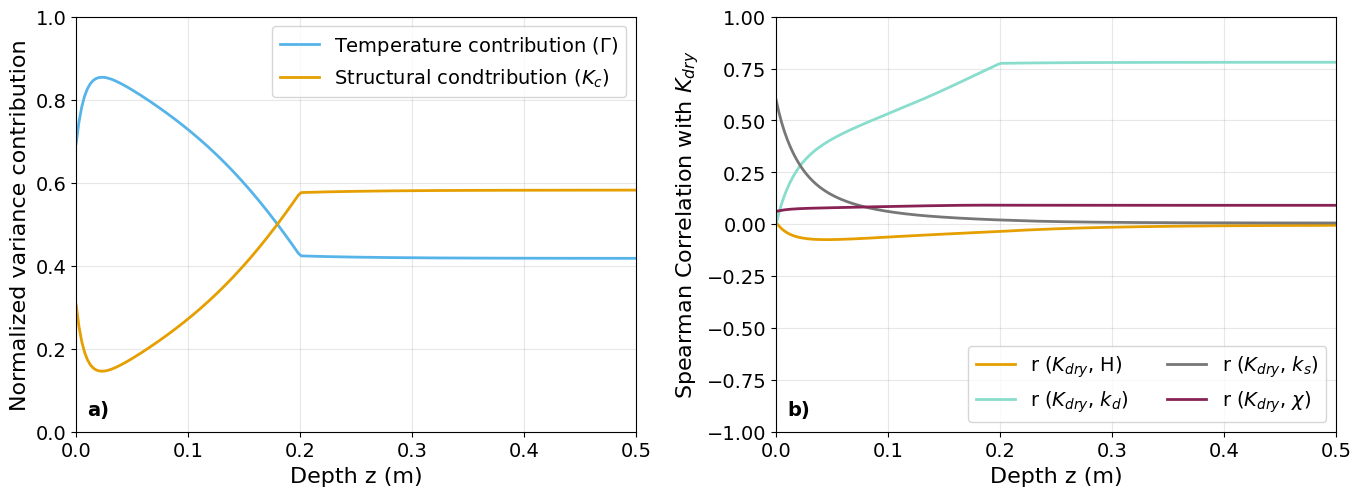

In [ ]:
# -------------------------
# PLOT
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.12,
    top=0.95,
    wspace=0.25  # horizontal space between plots
)

# --- (a) Variance contributions
axs[0].plot(z_vals, S_T, linewidth=2, label=r"Temperature contribution ($\Gamma$)", color = colors[1])
axs[0].plot(z_vals, S_a, linewidth=2, label=r"Structural condtribution ($K_c$)", color = colors[0])

axs[0].set_xlabel("Depth z (m)", fontsize=16)
axs[0].set_ylabel("Normalized variance contribution", fontsize=16)
axs[0].set_xlim(0, 0.5)
axs[0].set_ylim(0, 1)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=14)
axs[0].tick_params(labelsize = 14)

axs[0].text(0.02, 0.075, "a)", transform=axs[0].transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left", color="black")


axs[1].plot(z_vals, corr_H, label=r'r ($K_{dry}$, H)', linewidth=2, color = colors[0])
axs[1].plot(z_vals, corr_Kd, label=r'r ($K_{dry}$, $k_d$)', linewidth=2, color = colors[8])
axs[1].plot(z_vals, corr_Ks, label=r'r ($K_{dry}$, $k_s$)', linewidth=2, color = colors[9])
axs[1].plot(z_vals, corr_Chi, label=r'r ($K_{dry}$, $\chi$)', linewidth=2, color = colors[10])

axs[1].set_xlabel("Depth z (m)", fontsize=16)
axs[1].set_ylabel("Spearman Correlation with $K_{dry}$", fontsize=16)
axs[1].set_ylim(-1,1)
axs[1].set_xlim([0, 0.5])
axs[1].tick_params(labelsize = 14)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize = 14, loc = "lower right", ncol = 2)

axs[1].text(0.02, 0.075, "b)", transform=axs[1].transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left", color="black")

# -------------------------
# SAVE
# -------------------------
save_folder = os.path.join(root_folder, "Icy", "k")
os.makedirs(save_folder, exist_ok=True)

plt.savefig(
    os.path.join(save_folder, "variance_VM_contributions.pdf"),
    dpi=300
)

# -------------------------
# SAVE
# -------------------------
save_folder = os.path.join(root_folder, "Dry", "k")
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "combined_k_figure.pdf"))
plt.show()


### Correlation of icy k

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


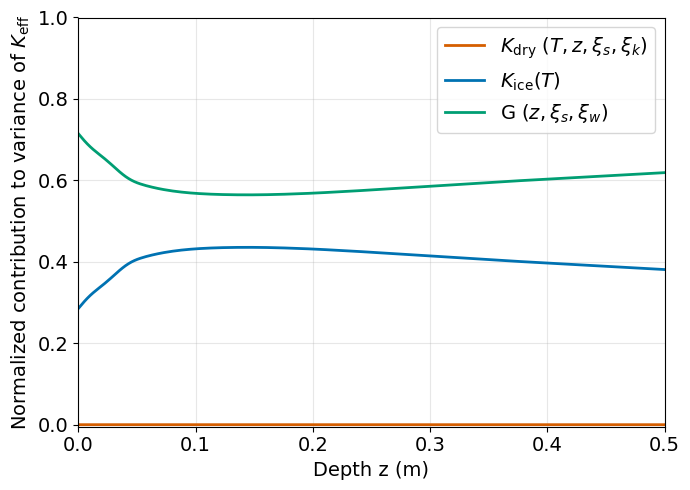

In [ ]:
S_dry = np.zeros(Nz)
S_ice_cond = np.zeros(Nz)
S_filling = np.zeros(Nz)


# -------------------------
# LOOP DEPTH
# -------------------------
for iz, z in enumerate(z_vals):

    # -------------------------
    # Temperature
    # -------------------------
    T = T_icy

    # -------------------------
    # STRUCTURE
    # -------------------------
    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )

    Cr = get_Cr(rho, z, H=H, rho_s=rho_s, rho_d=rho_d)

    phi = porosity(rho, rho_basalt=rho_basalt)

    PFF = pore_filling_fraction(z, Cr, phi, H=H, rho_s=rho_s, rho_d=rho_d)

    ice_fraction = PFF * phi 

    # -------------------------
    # CONDUCTIVITY
    # -------------------------
    Kdry = K_Hayne_2017(T, z, H=H, Kd=Kd, Ks=Ks, Chi=Chi)
    Kice = k_ice_Hobbs_1974(T)

    K = Kdry + Kice * ice_fraction

    # =================================================
    # VARIANCE DECOMPOSITION
    # =================================================

    Kdry_bar = np.mean(Kdry)
    Kice_bar = np.mean(Kice)
    ice_frac_bar = np.mean(ice_fraction)

    # --- 1. Dry contribution ---
    K_dry_only = Kdry + Kice_bar * ice_frac_bar
    Var_dry = np.var(K_dry_only)

    # --- 2. Ice conductivity (temperature-driven) ---
    K_ice_only = Kdry_bar + Kice * ice_frac_bar
    Var_ice_cond = np.var(K_ice_only)

    # --- 3. Ice filling (Fφ) ---
    K_filling_only = Kdry_bar + Kice_bar * ice_fraction
    Var_filling = np.var(K_filling_only)

    # --- Normalize ---
    denom = Var_dry + Var_ice_cond + Var_filling + 1e-12

    S_dry[iz] = Var_dry / denom
    S_ice_cond[iz] = Var_ice_cond / denom
    S_filling[iz] = Var_filling / denom


# =================================================
# PLOT
# =================================================

plt.figure(figsize=(7,5))

plt.plot(
    z_vals,
    S_dry,
    linewidth=2,
    label=r"$K_{\mathrm{dry}}$ ($T,z,\xi_s, \xi_k$)",
    color = colors[3]
)

plt.plot(
    z_vals,
    S_ice_cond,
    linewidth=2,
    label=r"$K_{\mathrm{ice}}(T)$",
    color = colors[4]
)

plt.plot(
    z_vals,
    S_filling,
    linewidth=2,
    label=r"G ($z,\xi_s, \xi_w$)",
    color = colors[2]
)

plt.xlabel(
    "Depth z (m)",
    fontsize=14
)

plt.ylabel(
    r"Normalized contribution to variance of $K_{\mathrm{eff}}$",
    fontsize=14
)

plt.xlim(0, 0.5)
plt.ylim(-0.005, 1)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)


plt.grid(alpha=0.3)

plt.legend(fontsize=14, ncol = 1, loc="upper right")

plt.tight_layout()

# -------------------------
# SAVE
# -------------------------
save_folder = os.path.join(root_folder, "Icy", "k")
os.makedirs(save_folder, exist_ok=True)

plt.savefig(
    os.path.join(save_folder, "variance_VM_contributions.pdf"),
    dpi=300
)

plt.show()

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


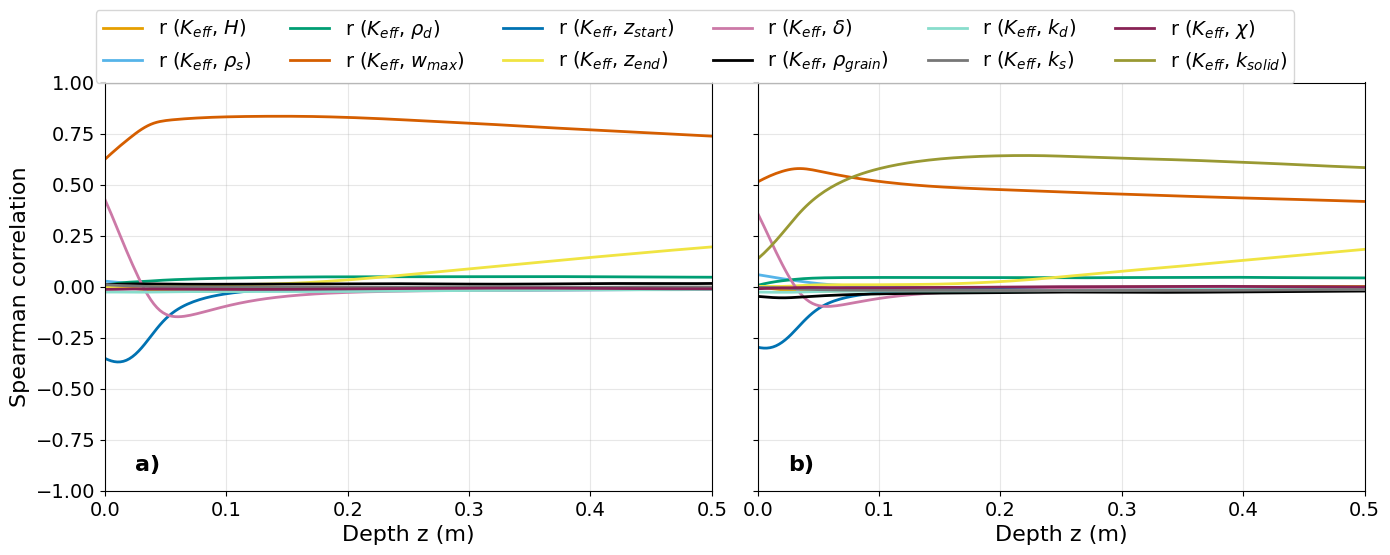

In [94]:
k_models = ["VM", "GB"]
corr_all = {}


# ==========================================================
# LOOP OVER MODELS
# ==========================================================

for k_model in k_models:

    corr = {
        "H": [],
        "Kd": [],
        "Ks": [],
        "Chi": [],
        "rho_s": [],
        "rho_d": [],
        "wt": [],
        "z_start": [],
        "z_end": [],
        "delta": [],
        "rho_basalt": [],
        "k_solid": []
    }


    for z in z_vals:

        # -------------------------
        # Sample parameters
        # -------------------------

        T = T_icy

        # -------------------------
        # Structure
        # -------------------------

        rho = rho_effective_carlos_new2(
            np.full(Nmc, z),
            H=H,
            rho_s=rho_s,
            rho_d=rho_d,
            wt_max=wt_max,
            z_start=z_start,
            z_end=z_end,
            dz=dz
        )

        Cr = get_Cr(
            rho,
            np.full(Nmc, z),
            H=H,
            rho_s=rho_s,
            rho_d=rho_d
        )

        phi = porosity(
            rho,
            rho_basalt=rho_basalt
        )

        PFF = pore_filling_fraction(
            np.full(Nmc, z),
            Cr,
            phi,
            H=H,
            rho_s=rho_s,
            rho_d=rho_d
        )


        # -------------------------
        # Conductivity
        # -------------------------

        if k_model == "VM":

            K = k_eff(
                T,
                np.full(Nmc, z),
                phi=phi,
                PFF=PFF,
                H=H,
                Kd=Kd,
                Ks=Ks,
                Chi=Chi
            )

        else:

            K = k_eff_Mellon_1997_new(
                T,
                np.full(Nmc, z),
                phi=phi,
                PFF=PFF,
                H=H,
                Kd=Kd,
                Ks=Ks,
                Chi=Chi,
                k_solid=k_solid
            )


        # -------------------------
        # Correlation
        # -------------------------

        df = pd.DataFrame({

            "H": H,
            "Kd": Kd,
            "Ks": Ks,
            "Chi": Chi,
            "rho_s": rho_s,
            "rho_d": rho_d,
            "wt": wt_max,
            "z_start": z_start,
            "z_end": z_end,
            "delta": dz,
            "rho_basalt": rho_basalt,
            "k_solid": k_solid,
            "K": K

        })


        c = df.corr(
            method="spearman"
        )


        for param in corr.keys():

            corr[param].append(
                c.loc["K", param]
            )


    corr_all[k_model] = {
        key: np.array(value)
        for key, value in corr.items()
    }



# ==========================================================
# PLOT 1x2
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5),
    sharey=True
)


plot_params = {
    "H": r"$H$",
    "rho_s": r"$\rho_s$",
    "rho_d": r"$\rho_d$",
    "wt": r"$w_{max}$",
    "z_start": r"$z_{{start}}$",
    "z_end": r"$z_{end}$",
    "delta": r"$\delta$",
    "rho_basalt": r"$\rho_{grain}$",
    "Kd": r"$k_d$",
    "Ks": r"$k_s$",
    "Chi": r"$\chi$",
    "k_solid": r"$k_{solid}$"

}


for i, (ax, model) in enumerate(zip(axes, k_models)):
    
    idx = 0
    for param, label in plot_params.items():

        if model == "VM" and param == "k_solid":
            continue

        ax.plot(
            z_vals,
            corr_all[model][param],
            linewidth=2,
            label=rf"r $(K_{{eff}}$, {label})",
            color = colors[idx]
        )
        idx=idx+1

    ax.set_xlim(
        0,
        0.5
    )

    ax.set_ylim(
        -1,
        1
    )

    ax.grid(
        alpha=0.3
    )

    ax.text(
        0.05,
        0.05,
        chr(97+i)+")",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )


    ax.set_xlabel(
        "Depth z (m)",
        fontsize=16
    )

    ax.tick_params(
        labelsize=14
    )


axes[0].set_ylabel(
    "Spearman correlation",
    fontsize=16
)


# ==========================================================
# SINGLE LEGEND ABOVE
# ==========================================================

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    fontsize=14,
    ncols=6,
    frameon=True
)


plt.tight_layout()


# ==========================================================
# SAVE
# ==========================================================

save_folder = os.path.join(
    root_folder,
    "Icy",
    "k"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "correlation_VM_vs_GB.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

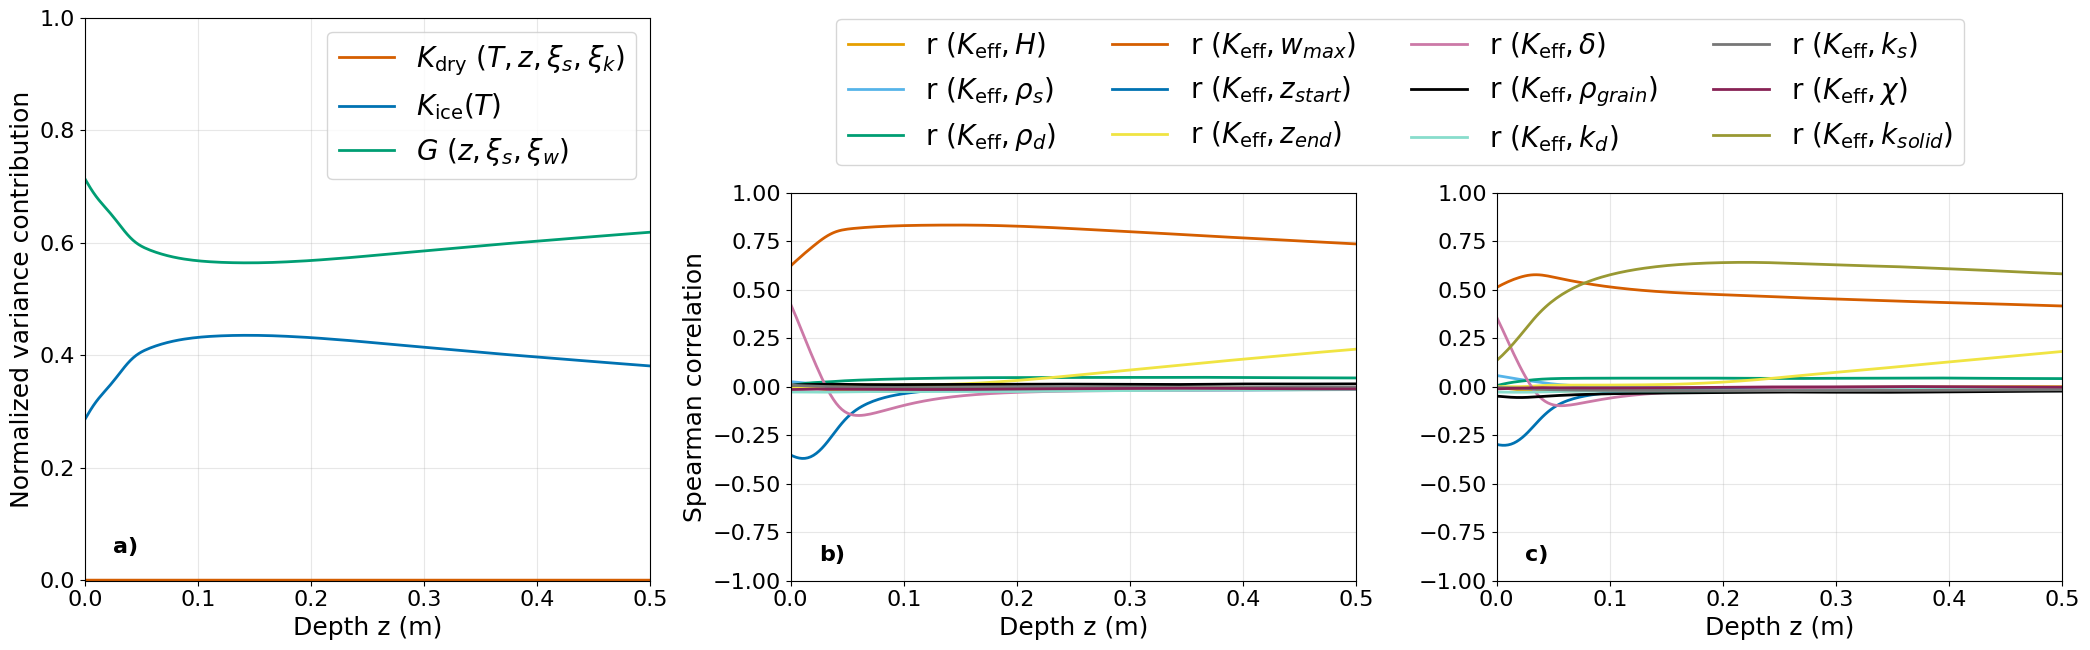

In [ ]:
# ==========================================================
# COMBINED 1x3 FIGURE
# ==========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(21,5),
    sharex=True
)

plot_params = {
    "H": r"H",
    "rho_s": r"\rho_s",
    "rho_d": r"\rho_d",
    "wt": r"w_{max}",
    "z_start": r"z_{start}",
    "z_end": r"z_{end}",
    "delta": r"\delta",
    "rho_basalt": r"\rho_{grain}",
    "Kd": r"k_d",
    "Ks": r"k_s",
    "Chi": r"\chi",
    "k_solid": r"k_{solid}"
}

# ==========================================================
# (a) NORMALIZED VARIANCE
# ==========================================================

ax = axes[0]

ax.plot(z_vals, S_dry, linewidth=2,
        label=r"$K_{\mathrm{dry}}$ ($T,z,\xi_s,\xi_k$)",
        color=colors[3])

ax.plot(z_vals, S_ice_cond, linewidth=2,
        label=r"$K_{\mathrm{ice}}(T)$",
        color=colors[4])

ax.plot(z_vals, S_filling, linewidth=2,
        label=r"$G$ ($z,\xi_s,\xi_w$)",
        color=colors[2])

ax.set_ylabel(r"Normalized variance contribution", fontsize=18)
ax.set_xlim(0, 0.5)
ax.set_ylim(-0.001, 1)
ax.grid(alpha=0.3)
ax.text(0.05, 0.05, "a)", transform=ax.transAxes,
        fontsize=16, fontweight="bold")


# ==========================================================
# (b) VM CORRELATIONS
# ==========================================================

ax = axes[1]

idx = 0
for param, label in plot_params.items():

    if param == "k_solid":
        continue

    ax.plot(z_vals, corr_all["VM"][param],
            linewidth=2,
            label=rf"r $(K_{{\mathrm{{eff}}}}, {label})$",
            color=colors[idx])
    idx += 1

ax.set_xlim(0, 0.5)
ax.set_ylim(-1, 1)
ax.grid(alpha=0.3)
ax.text(0.05, 0.05, "b)", transform=ax.transAxes,
        fontsize=16, fontweight="bold")


# ==========================================================
# (c) GB CORRELATIONS
# ==========================================================

ax = axes[2]

idx = 0
for param, label in plot_params.items():

    ax.plot(z_vals, corr_all["GB"][param],
            linewidth=2,
            label=rf"r $(K_{{\mathrm{{eff}}}}, {label})$",
            color=colors[idx])
    idx += 1

ax.set_xlim(0, 0.5)
ax.set_ylim(-1, 1)
ax.grid(alpha=0.3)
ax.text(0.05, 0.05, "c)", transform=ax.transAxes,
        fontsize=16, fontweight="bold")


# ==========================================================
# COMMON LABELS
# ==========================================================

for ax in axes:
    ax.set_xlabel("Depth z (m)", fontsize=18)
    ax.tick_params(labelsize=16)

axes[1].set_ylabel("Spearman correlation", fontsize=18)

axes[0].legend(
    fontsize=20,
    loc="upper right",
    ncols = 1)


# --- (b–c) shared legend centered over panels b and c ---
handles, labels = axes[2].get_legend_handles_labels()

pos1 = axes[1].get_position()
pos2 = axes[2].get_position()
x_center_bc = (pos1.x0 + pos2.x1) / 2 + 0.02

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(x_center_bc, 1.3),  # tighter spacing
    fontsize=20,
    ncols=4,
    frameon=True
)


# ==========================================================
# LAYOUT
# ==========================================================

plt.tight_layout(rect=[0, 0, 1, 0.92])

pos = axes[0].get_position()

axes[0].set_position([
    pos.x0,
    pos.y0, 
    pos.width,
    pos.height + 0.4
])

pos = axes[1].get_position()

axes[1].set_position([
    pos.x0,
    pos.y0,
    pos.width,
    pos.height + 0.05
])

pos = axes[2].get_position()

axes[2].set_position([
    pos.x0,
    pos.y0,
    pos.width,
    pos.height + 0.05
])

# ==========================================================
# SAVE
# ==========================================================

plt.savefig(
    os.path.join(save_folder, "combined_variance_correlation.pdf"),
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Ratio of GB/VM conductivity, general

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


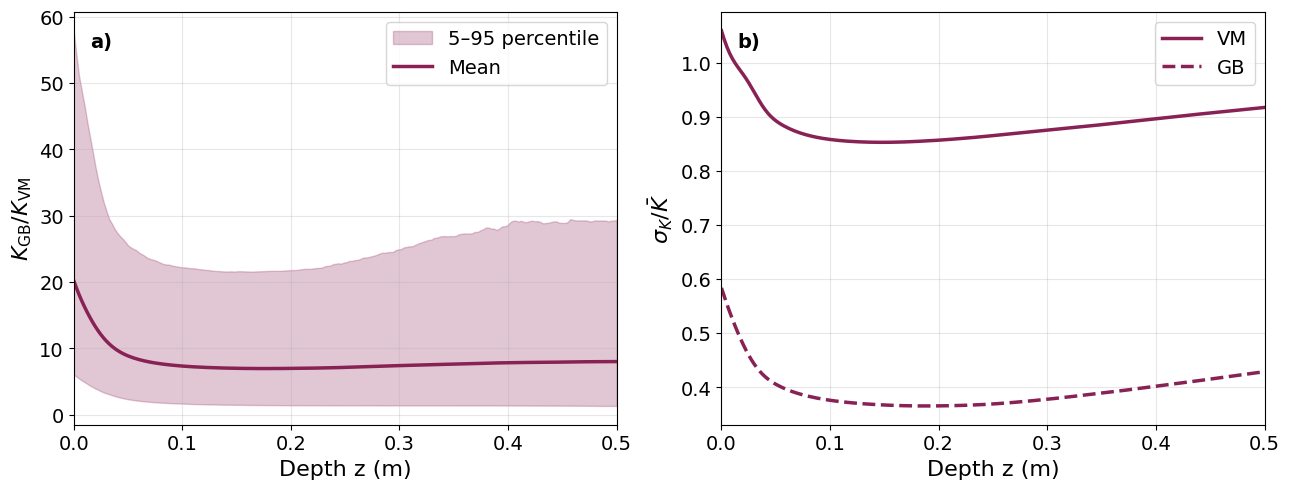

In [ ]:
corr_H = []
corr_Kd = []
corr_Ks = []
corr_Chi = []
corr_rho_s = []
corr_rho_d = []
corr_wt = []
corr_z_start = []
corr_z_end = []
corr_delta = []
corr_rho_basalt = []
corr_k_solid = []

ratio_mean = []
ratio_p05 = []
ratio_p95 = []

std_vm = []
std_gb = []

cv_vm = []
cv_gb = []



# ==========================================================
# LOOP OVER DEPTH
# ==========================================================

for z in z_vals:
    
    T = T_icy

    # -------------------------
    # Density and porosity
    # -------------------------

    rho = rho_effective_carlos_new2(
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )


    Cr = get_Cr(
        rho,
        np.full(Nmc, z),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d
    )


    phi = porosity(
        rho,
        rho_basalt=rho_basalt
    )


    PFF = pore_filling_fraction(
        np.full(Nmc, z),
        Cr,
        phi,
        H=H,
        rho_s=rho_s,
        rho_d=rho_d
    )



    # -------------------------
    # Conductivities
    # -------------------------

    k_vm = k_eff(
        T,
        np.full(Nmc, z),
        phi=phi,
        PFF=PFF,
        H=H,
        Kd=Kd,
        Ks=Ks,
        Chi=Chi
    )


    k_gb = k_eff_Mellon_1997_new(
        T,
        np.full(Nmc, z),
        phi=phi,
        PFF=PFF,
        H=H,
        Kd=Kd,
        Ks=Ks,
        Chi=Chi,
        k_solid=k_solid
    )



    # ======================================================
    # GB / VM RATIO
    # ======================================================

    ratio = k_gb / k_vm


    ratio_mean.append(
        np.mean(ratio)
    )

    ratio_p05.append(
        np.percentile(ratio, 5)
    )

    ratio_p95.append(
        np.percentile(ratio, 95)
    )



    # ======================================================
    # CONDUCTIVITY VARIABILITY
    # ======================================================

    std_vm.append(
        np.std(k_vm)
    )

    std_gb.append(
        np.std(k_gb)
    )


    cv_vm.append(
        np.std(k_vm) / np.mean(k_vm)
    )

    cv_gb.append(
        np.std(k_gb) / np.mean(k_gb)
    )



    # ======================================================
    # SELECT MODEL FOR CORRELATIONS
    # ======================================================

    if k_model == "VM":

        k_icy = k_vm

    else:

        k_icy = k_gb



    # ======================================================
    # CORRELATION ANALYSIS
    # ======================================================

    df = pd.DataFrame({

        'H': H,
        'Kd': Kd,
        'Ks': Ks,
        'Chi': Chi,
        'rho_s': rho_s,
        'rho_d': rho_d,
        'wt': wt_max,
        'z_start': z_start,
        'z_end': z_end,
        'delta': dz,
        'rho_basalt': rho_basalt,
        'k_solid': k_solid,
        'K': k_icy

    })


    corr = df.corr(
        method="spearman"
    )


    corr_H.append(
        corr.loc['K','H']
    )

    corr_Kd.append(
        corr.loc['K','Kd']
    )

    corr_Ks.append(
        corr.loc['K','Ks']
    )

    corr_Chi.append(
        corr.loc['K','Chi']
    )

    corr_rho_s.append(
        corr.loc['K','rho_s']
    )

    corr_rho_d.append(
        corr.loc['K','rho_d']
    )

    corr_wt.append(
        corr.loc['K','wt']
    )

    corr_z_start.append(
        corr.loc['K','z_start']
    )

    corr_z_end.append(
        corr.loc['K','z_end']
    )

    corr_delta.append(
        corr.loc['K','delta']
    )

    corr_rho_basalt.append(
        corr.loc['K','rho_basalt']
    )

    corr_k_solid.append(
        corr.loc['K','k_solid']
    )



# ==========================================================
# ARRAYS
# ==========================================================

ratio_mean = np.asarray(ratio_mean)
ratio_p05 = np.asarray(ratio_p05)
ratio_p95 = np.asarray(ratio_p95)


std_vm = np.asarray(std_vm)
std_gb = np.asarray(std_gb)

cv_vm = np.asarray(cv_vm)
cv_gb = np.asarray(cv_gb)



# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,5)
)



# ==========================================================
# a) GB / VM ratio
# ==========================================================

ax = axes[0]


ax.fill_between(
    z_vals,
    ratio_p05,
    ratio_p95,
    color=colors[10],
    alpha=0.25,
    label="5–95 percentile"
)


ax.plot(
    z_vals,
    ratio_mean,
    color=colors[10],
    linewidth=2.5,
    label="Mean"
)


ax.text(
    0.03,
    0.95,
    "a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)


ax.set_xlabel(
    "Depth z (m)",
    fontsize=16
)


ax.set_ylabel(
    r"$K_{\rm GB}/K_{\rm VM}$",
    fontsize=16
)


ax.set_xlim(
    0,
    0.5
)


ax.tick_params(
    axis="both",
    labelsize=14
)


ax.grid(
    alpha=0.3
)


ax.legend(
    fontsize=14
)



# ==========================================================
# b) Relative variability
# ==========================================================

ax = axes[1]


ax.plot(
    z_vals,
    cv_vm,
    linewidth=2.5,
    label="VM",
    color=colors[10]
)


ax.plot(
    z_vals,
    cv_gb,
    linewidth=2.5,
    linestyle="--",
    label="GB",
    color=colors[10]
)


ax.text(
    0.03,
    0.95,
    "b)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)


ax.set_xlabel(
    "Depth z (m)",
    fontsize=16
)


ax.set_ylabel(
    r"$\sigma_K/\bar K$",
    fontsize=16
)


ax.set_xlim(
    0,
    0.5
)


ax.tick_params(
    axis="both",
    labelsize=14
)


ax.grid(
    alpha=0.3
)


ax.legend(
    fontsize=14
)



plt.tight_layout()



save_folder = os.path.join(
    root_folder,
    "Icy",
    "k"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "GB_VM_ratio_variability.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Electromagnetic / radiative properties

### Loss Tangents

In [ ]:
def compute_correlations(m_or_h):

    if m_or_h == "highland":
        S_TiO2 = np.random.uniform(0, 1, Nmc)
    elif m_or_h == "mare":
        S_TiO2 = sample_tio2(Nmc)

    # Feng valid frequencies (MRM only)
    freq_mrm = np.array([3, 7.8, 19.35, 37])
    freq = np.random.choice(freq_mrm,  Nmc)

    # Carrier
    corr_carrier_H = []
    corr_carrier_rho_s = []
    corr_carrier_rho_d = []
    corr_carrier_STiO2 = []


    # Feng
    corr_feng_H = []
    corr_feng_rho_s = []
    corr_feng_rho_d = []
    corr_feng_freq = []
    corr_feng_STiO2 = []


    # =====================================================
    # LOOP OVER DEPTH
    # =====================================================

    for z in z_vals:

        rho = rho_effective_carlos_new2(
            np.full(Nmc, z),
            H=H,
            rho_s=rho_s,
            rho_d=rho_d
        )


        # =================================================
        # CARRIER MODEL
        # =================================================

        tan_delta_carrier = loss_tangent_carrier_1991(
            rho,
            S_TiO2
        )


        df_carrier = pd.DataFrame({

            "H": H,
            "rho_s": rho_s,
            "rho_d": rho_d,
            "S_TiO2": S_TiO2,
            "tan_delta": tan_delta_carrier

        })


        corr = df_carrier.corr()


        corr_carrier_H.append(
            corr.loc["H","tan_delta"]
        )

        corr_carrier_rho_s.append(
            corr.loc["rho_s","tan_delta"]
        )

        corr_carrier_rho_d.append(
            corr.loc["rho_d","tan_delta"]
        )

        corr_carrier_STiO2.append(
            corr.loc["S_TiO2","tan_delta"]
        )



        # =================================================
        # FENG MODEL
        # =================================================

        # frequency is an independent parameter
        # only valid MRM frequencies

        if m_or_h == "highland":
            tan_delta_feng = loss_tangent_feng_2021_highland(rho, freq)
            
            df_feng = pd.DataFrame({
                "H": H,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "freq": freq,
                "tan_delta": tan_delta_feng})
            
        elif m_or_h == "mare":
            tan_delta_feng = loss_tangent_feng_2021_mare(rho, freq, S_TiO2)

            df_feng = pd.DataFrame({
                "H": H,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "freq": freq,
                "S_TiO2": S_TiO2,
                "tan_delta": tan_delta_feng})

        corr = df_feng.corr()


        corr_feng_H.append(
            corr.loc["H","tan_delta"]
        )

        corr_feng_rho_s.append(
            corr.loc["rho_s","tan_delta"]
        )

        corr_feng_rho_d.append(
            corr.loc["rho_d","tan_delta"]
        )

        corr_feng_freq.append(
            corr.loc["freq","tan_delta"]
        )
        
        if m_or_h == "mare":
            corr_feng_STiO2.append(
            corr.loc["S_TiO2","tan_delta"]
        )



    # =====================================================
    # ARRAYS
    # =====================================================
    
    return {
    "carrier_H": np.array(corr_carrier_H),
    "carrier_rho_s": np.array(corr_carrier_rho_s),
    "carrier_rho_d": np.array(corr_carrier_rho_d),
    "carrier_STiO2": np.array(corr_carrier_STiO2),

    "feng_H": np.array(corr_feng_H),
    "feng_rho_s": np.array(corr_feng_rho_s),
    "feng_rho_d": np.array(corr_feng_rho_d),
    "feng_freq": np.array(corr_feng_freq),
    "feng_STiO2": np.array(corr_feng_STiO2)
}
    
corr_mare = compute_correlations("mare")
corr_high = compute_correlations("highland")

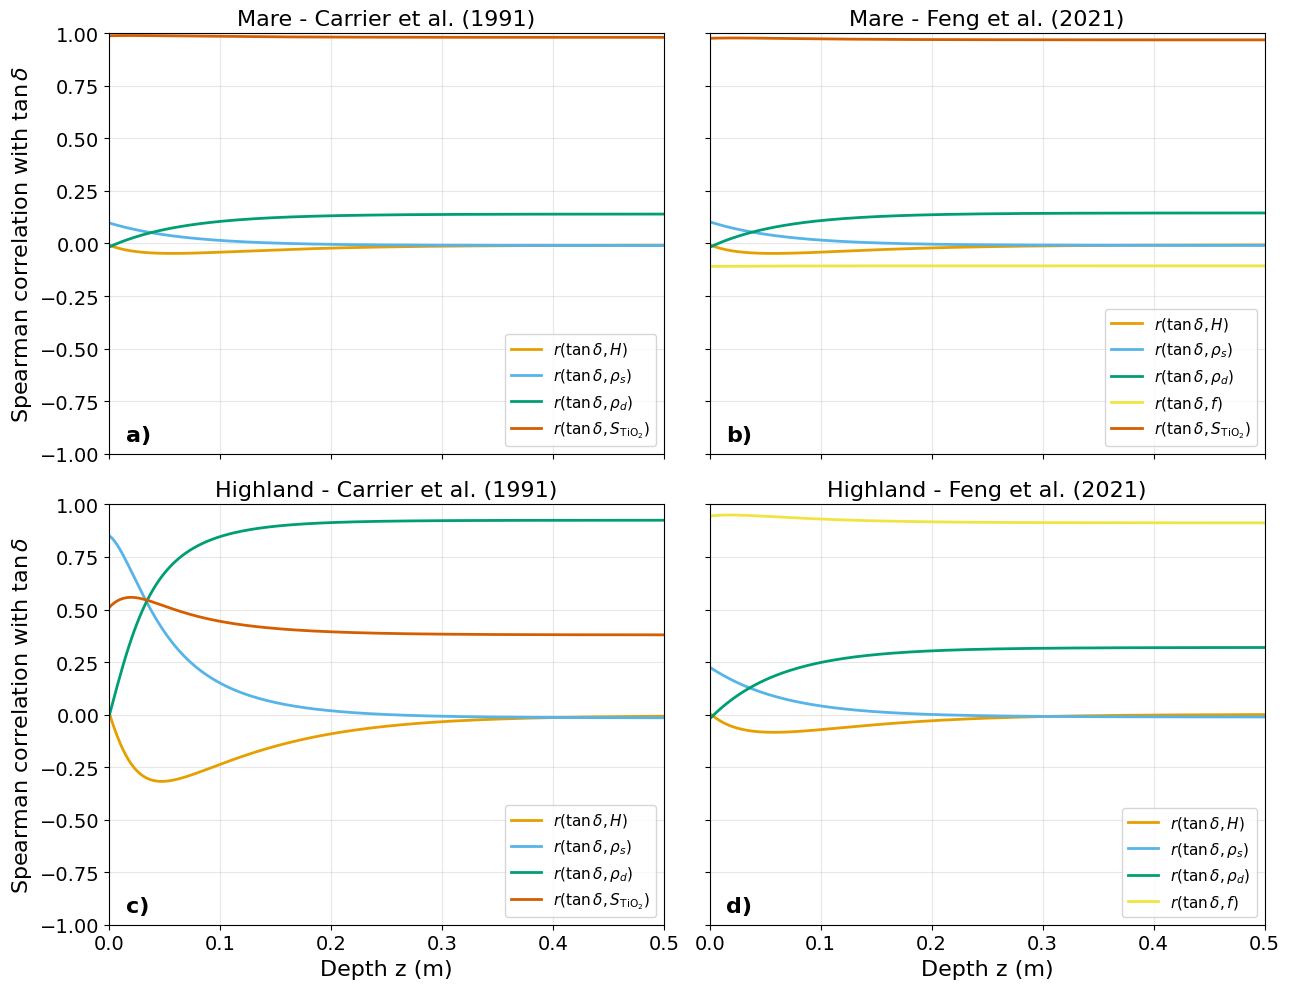

In [ ]:
# =====================================================
# COMBINED FIGURE: Carrier + Feng
# =====================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13,10),
    sharex=True,
    sharey=True
)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.15
)


# =====================================================
# (a) CARRIER
# =====================================================

datasets = [
    ("Mare", corr_mare),
    ("Highland", corr_high)
]

letters = [["a)", "b)"],
           ["c)", "d)"]]

for row, (title, data) in enumerate(datasets):

    # ------------------------
    # Carrier
    # ------------------------

    ax = axes[row,0]

    ax.plot(z_vals, data["carrier_H"], lw=2,
            color=colors[0], label=r"$r(\tan\delta,H)$")

    ax.plot(z_vals, data["carrier_rho_s"], lw=2,
            color=colors[1], label=r"$r(\tan\delta,\rho_s)$")

    ax.plot(z_vals, data["carrier_rho_d"], lw=2,
            color=colors[2], label=r"$r(\tan\delta,\rho_d)$")

    ax.plot(z_vals, data["carrier_STiO2"], lw=2,
            color=colors[3],
            label=r"$r(\tan\delta,S_{\mathrm{TiO_2}})$")

    ax.set_title(f"{title} - Carrier et al. (1991)", fontsize=16)

    ax.grid(alpha=0.3)

    ax.text(
        0.03,0.03,
        letters[row][0],
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )

    # ------------------------
    # Feng
    # ------------------------

    ax = axes[row,1]

    ax.plot(z_vals, data["feng_H"], lw=2,
            color=colors[0], label=r"$r(\tan\delta,H)$")

    ax.plot(z_vals, data["feng_rho_s"], lw=2,
            color=colors[1], label=r"$r(\tan\delta,\rho_s)$")

    ax.plot(z_vals, data["feng_rho_d"], lw=2,
            color=colors[2], label=r"$r(\tan\delta,\rho_d)$")

    ax.plot(z_vals, data["feng_freq"], lw=2,
            color=colors[5], label=r"$r(\tan\delta,f)$")

    if title == "Mare":
        ax.plot(
            z_vals,
            data["feng_STiO2"],
            lw=2,
            color=colors[3],
            label=r"$r(\tan\delta,S_{\mathrm{TiO_2}})$"
        )

    ax.set_title(f"{title} - Feng et al. (2021)", fontsize=16)

    ax.grid(alpha=0.3)

    ax.text(
        0.03,0.03,
        letters[row][1],
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )


for ax in axes[:,0]:
    ax.set_ylabel(r"Spearman correlation with $\tan\delta$", fontsize=16)

for ax in axes[1,:]:
    ax.set_xlabel("Depth z (m)", fontsize=16)

for ax in axes.ravel():
    ax.set_xlim(0,0.5)
    ax.set_ylim(-1,1)
    ax.tick_params(labelsize=14)
    ax.set_yticks(np.linspace(-1,1,9))
    ax.legend(fontsize=11, loc="lower right")
    
plt.tight_layout()


# =====================================================
# SAVE
# =====================================================

save_folder = os.path.join(
    root_folder,
    "Dry",
    "Dielectric"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        f"correlation_plot_Carrier_Feng.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

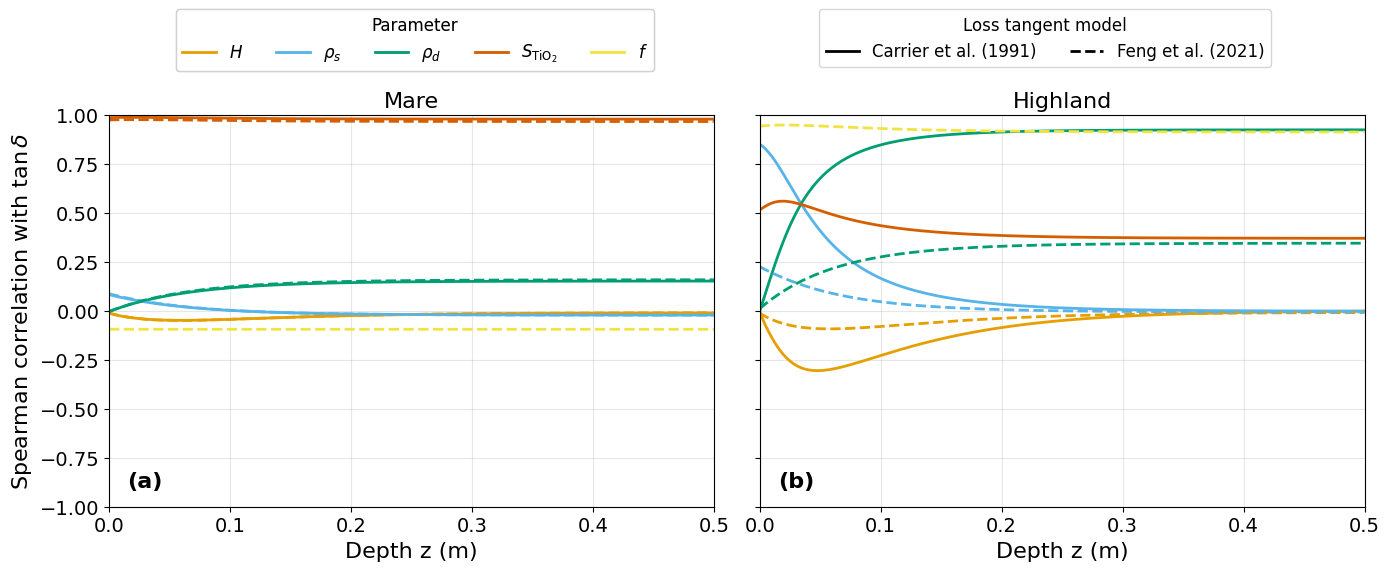

In [131]:
# =====================================================
# COMBINED FIGURE: Mare vs Highland
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5),
    sharex=True,
    sharey=True
)


datasets = [
    ("Mare", corr_mare, axes[0]),
    ("Highland", corr_high, axes[1])
]


# line styles for loss tangent formulations
styles = {
    "carrier": "-",
    "feng": "--"
}


# =====================================================
# PLOT
# =====================================================

for title, data, ax in datasets:

    # ------------------------
    # Carrier
    # ------------------------

    ax.plot(
        z_vals,
        data["carrier_H"],
        lw=2,
        ls=styles["carrier"],
        color=colors[0],
        label=r"$H$"
    )

    ax.plot(
        z_vals,
        data["carrier_rho_s"],
        lw=2,
        ls=styles["carrier"],
        color=colors[1],
        label=r"$\rho_s$"
    )

    ax.plot(
        z_vals,
        data["carrier_rho_d"],
        lw=2,
        ls=styles["carrier"],
        color=colors[2],
        label=r"$\rho_d$"
    )

    ax.plot(
        z_vals,
        data["carrier_STiO2"],
        lw=2,
        ls=styles["carrier"],
        color=colors[3],
        label=r"$S_{\mathrm{TiO_2}}$"
    )


    # ------------------------
    # Feng
    # ------------------------

    ax.plot(
        z_vals,
        data["feng_H"],
        lw=2,
        ls=styles["feng"],
        color=colors[0]
    )

    ax.plot(
        z_vals,
        data["feng_rho_s"],
        lw=2,
        ls=styles["feng"],
        color=colors[1]
    )

    ax.plot(
        z_vals,
        data["feng_rho_d"],
        lw=2,
        ls=styles["feng"],
        color=colors[2]
    )


    ax.plot(
        z_vals,
        data["feng_freq"],
        lw=2,
        ls=styles["feng"],
        color=colors[5],
        label=r"$f$"
    )


    if title == "Mare":

        ax.plot(
            z_vals,
            data["feng_STiO2"],
            lw=2,
            ls=styles["feng"],
            color=colors[3]
        )


    ax.set_title(
        title,
        fontsize=16
    )


    ax.grid(
        alpha=0.3
    )


    ax.text(
        0.03,
        0.05,
        "(a)" if title=="Mare" else "(b)",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )


# =====================================================
# AXIS
# =====================================================

for ax in axes:

    ax.set_xlim(
        0,
        0.5
    )

    ax.set_ylim(
        -1,
        1
    )

    ax.set_xlabel(
        "Depth z (m)",
        fontsize=16
    )

    ax.tick_params(
        labelsize=14
    )

    ax.set_yticks(
        np.linspace(-1,1,9)
    )


axes[0].set_ylabel(
    r"Spearman correlation with $\tan\delta$",
    fontsize=16
)



# =====================================================
# LEGENDS
# =====================================================

from matplotlib.lines import Line2D


# Parameter colours
handles_param = [
    Line2D(
        [],
        [],
        color=colors[0],
        lw=2,
        label=r"$H$"
    ),

    Line2D(
        [],
        [],
        color=colors[1],
        lw=2,
        label=r"$\rho_s$"
    ),

    Line2D(
        [],
        [],
        color=colors[2],
        lw=2,
        label=r"$\rho_d$"
    ),

    Line2D(
        [],
        [],
        color=colors[3],
        lw=2,
        label=r"$S_{\mathrm{TiO_2}}$"
    ),

    Line2D(
        [],
        [],
        color=colors[5],
        lw=2,
        label=r"$f$"
    )
]


legend1 = fig.legend(
    handles=handles_param,
    loc="upper center",
    bbox_to_anchor=(0.3,1.15),
    ncols=5,
    fontsize=12,
    frameon=True,
    title="Parameter",
    title_fontsize=12
)



# loss tangent styles
handles_model = [
    Line2D(
        [],
        [],
        color="black",
        lw=2,
        ls="-",
        label="Carrier et al. (1991)"
    ),

    Line2D(
        [],
        [],
        color="black",
        lw=2,
        ls="--",
        label="Feng et al. (2021)"
    )
]


legend2 = fig.legend(
    handles=handles_model,
    loc="upper center",
    bbox_to_anchor=(0.75,1.15),
    ncols=2,
    fontsize=12,
    frameon=True,
    title="Loss tangent model",
    title_fontsize=12
)


fig.add_artist(legend1)


plt.tight_layout()



# =====================================================
# SAVE
# =====================================================

plt.savefig(
    os.path.join(
        save_folder,
        "correlation_Carrier_Feng_Mare_Highland.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Correlation for permittivity, icy case

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


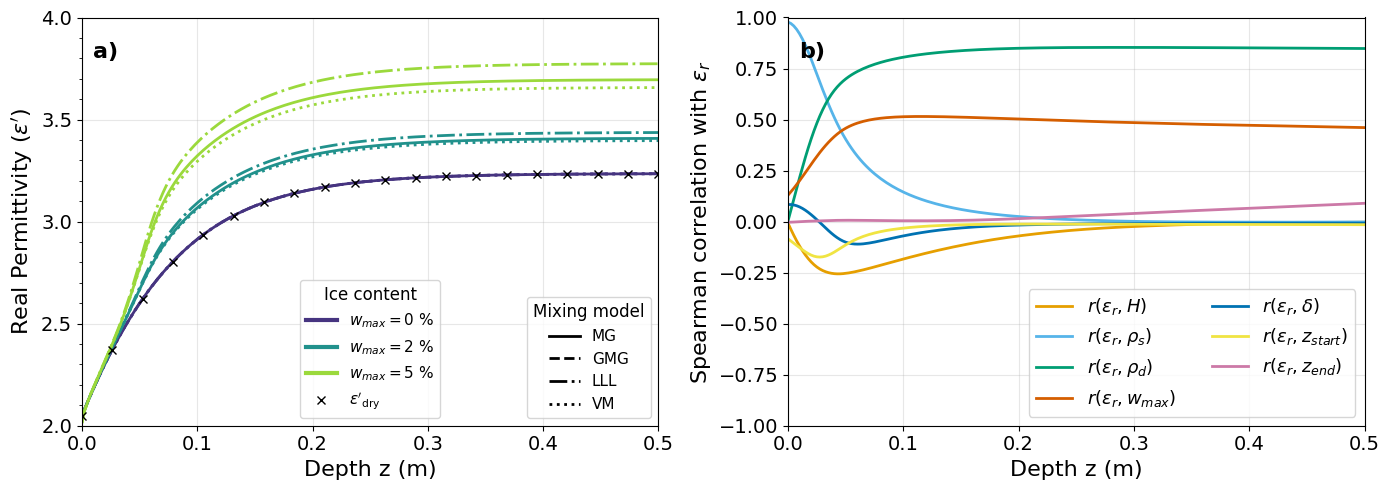

In [91]:
# =====================================================
# FIGURE SETUP
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5),
)

ax1, ax2 = axes


# =====================================================
# LEFT PANEL: PERMITTIVITY PROFILES
# =====================================================

wts = [0,2,5]

eps_GM_vector = []
eps_CS_vector = []
eps_VM_vector = []
eps_LLL_vector = []
rho_vector = []


for wt in wts:

    rho_val = rho_effective_carlos_new2(
        z_vals,
        wt_max=wt,
        z_start=0.05
    )
    
    rho_vector.append(rho_val)

    eps_GM_vector.append(
        dielectric_constant_GM(z_vals,rho_val)
    )

    eps_CS_vector.append(
        dielectric_constant_CS(z_vals,rho_val)
    )

    eps_VM_vector.append(
        dielectric_constant_regolith_icy_new(z_vals,rho_val)
    )

    eps_LLL_vector.append(
        dielectric_constant_LLL(z_vals,rho_val)
    )


ice_colors = {
    0: plt.cm.viridis(0.15),
    2: plt.cm.viridis(0.50),
    5: plt.cm.viridis(0.85)
}


model_styles = {
    "MG":"-",
    "GMG":"--",
    "LLL":"-.",
    "VM":":"
}


for idx, wt in enumerate(wts):

    c = ice_colors[wt]

    ax1.plot(
        z_vals,
        eps_GM_vector[idx],
        color=c,
        linestyle=model_styles["MG"],
        linewidth=2
    )

    ax1.plot(
        z_vals,
        eps_CS_vector[idx],
        color=c,
        linestyle=model_styles["GMG"],
        linewidth=2
    )

    ax1.plot(
        z_vals,
        eps_LLL_vector[idx],
        color=c,
        linestyle=model_styles["LLL"],
        linewidth=2
    )

    ax1.plot(
        z_vals,
        eps_VM_vector[idx],
        color=c,
        linestyle=model_styles["VM"],
        linewidth=2
    )


# dry reference

eps_dry = dielectric_constant_regolith(rho_effective_carlos_new2(np.linspace(0,0.5, 20)))

ax1.plot(
    np.linspace(0,0.5, 20),
    eps_dry,
    color="black",
    marker="x",
    linestyle="None",
    markersize=6
)


ax1.set_xlabel(
    "Depth z (m)",
    fontsize=16
)

ax1.set_ylabel(
    r"Real Permittivity ($\epsilon'$)",
    fontsize=16
)

ax1.set_xlim(0,0.5)
ax1.set_xticks(np.arange(0,0.6,0.1))

ax1.set_ylim(2,4)
ax1.set_yticks(np.arange(2,4.1,0.5))
ax1.set_yticks(np.arange(2,4.1,0.1),minor=True)

ax1.tick_params(labelsize=14)

ax1.grid(alpha=0.3)


# legends

model_handles = [
    Line2D(
        [0],[0],
        color="black",
        linestyle=model_styles[m],
        linewidth=2,
        label=m
    )
    for m in ["MG","GMG","LLL","VM"]
]


legend1 = ax1.legend(
    handles=model_handles,
    title="Mixing model",
    fontsize=11,
    title_fontsize=12,
    loc="lower right"
)

ax1.add_artist(legend1)


ice_handles = [
    Line2D(
        [0],[0],
        color=ice_colors[w],
        linewidth=3,
        label=rf"$w_{{max}}={w}$ %"
    )
    for w in wts
]


ax1.legend(
    handles=ice_handles + [
        Line2D(
            [0],[0],
            color="black",
            marker="x",
            linestyle="None",
            label=r"$\epsilon'_{\rm dry}$"
        )
    ],
    title="Ice content",
    fontsize=11,
    title_fontsize=12,
    loc="lower center"
)


ax1.text(
    0.02,
    0.9,
    "a)",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold"
)



# =====================================================
# RIGHT PANEL: CORRELATION
# =====================================================


parameters = [
    r"$H$",
    r"$\rho_s$",
    r"$\rho_d$",
    r"$w_{max}$",
    r"$\delta$",
    r"$z_{start}$",
    r"$z_{end}$"
]


corr = {p:[] for p in parameters}


for z0 in z_vals:


    rho = rho_effective_carlos_new2(
        np.full(Nmc,z0),
        H=H,
        rho_s=rho_s,
        rho_d=rho_d,
        wt_max=wt_max,
        z_start=z_start,
        z_end=z_end,
        dz=dz
    )


    eps = dielectric_constant_LLL(np.full(Nmc,z0),rho)
    # eps = dielectric_constant_CS(np.full(Nmc,z0),rho)


    df = pd.DataFrame({

        r"$H$":H,
        r"$\rho_s$":rho_s,
        r"$\rho_d$":rho_d,
        r"$w_{max}$":wt_max,
        r"$\delta$":dz,
        r"$z_{start}$":z_start,
        r"$z_{end}$":z_end,
        r"$\varepsilon_r$":eps

    })


    c = df.corr(method="spearman")

    for p in parameters:
        corr[p].append(
            c.loc[p,r"$\varepsilon_r$"]
        )


for i,p in enumerate(parameters):

    ax2.plot(
        z_vals,
        corr[p],
        linewidth=2,
        label=rf"$r(\epsilon_r,{p.strip('$')})$",
        color = colors[i]
    )


ax2.set_xlabel(
    "Depth z (m)",
    fontsize=16
)

ax2.set_ylabel(
    r"Spearman correlation with $\varepsilon_r$",
    fontsize=16
)

ax2.set_xlim(0,0.5)
ax2.set_ylim(-1,1)

ax2.tick_params(labelsize=14)

ax2.set_yticks(np.linspace(-1,1,9))

ax2.grid(alpha=0.3)

ax2.legend(
    fontsize=13,
    ncols=2,
    loc="lower right"
)


ax2.text(
    0.02,
    0.9,
    "b)",
    transform=ax2.transAxes,
    fontsize=16,
    fontweight="bold"
)


# =====================================================
# SAVE
# =====================================================

plt.tight_layout()

save_folder = os.path.join(
    root_folder,
    "Dry",
    "Dielectric"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "permittivity_combined.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Penetration Depth

In [133]:
save_folder = os.path.join(
    root_folder,
    "Dry",
    "Dielectric"
)

In [134]:
# =====================================================
# PENETRATION DEPTH FUNCTION (modified from weighting function in RadiativeTransfer.py)
# =====================================================

def penetration_depth(z, delta_z, eps, tan_delta, freq_GHz, threshold = 1e-4):
    # absorption coefficient
    k = compute_absorption_coefficient(freq_GHz * 1e9, eps, tan_delta)

    # reflection
    R = np.zeros(len(z))
    for i in range(len(z) - 1):
        R[i] = (np.sqrt(eps[i+1]) - np.sqrt(eps[i])) / (np.sqrt(eps[i+1]) + np.sqrt(eps[i]))

    # transmission
    tau = np.exp(-k * delta_z)

    # weighting function
    w = np.zeros(len(z))
    T_cum = 1.0

    for i in range(len(z)):
        w[i] = (1 - tau[i]) * (1 + abs(R[i])**2 * tau[i]) * T_cum
        if i < len(z) - 1:
            T_cum *= (1 - abs(R[i])**2) * tau[i]

    w = w / np.max(w)

    idx = np.where(w < threshold)[0]

    return z[idx[0]] if len(idx) > 0 else z[-1]

In [135]:
z_vals_aux = np.linspace(0, 30, 200)

delta_z = np.zeros_like(z_vals_aux)
delta_z[1:-1] = (z_vals_aux[2:] - z_vals_aux[:-2]) / 2
delta_z[0] = z_vals_aux[1] - z_vals_aux[0]
delta_z[-1] = z_vals_aux[-1] - z_vals_aux[-2]

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


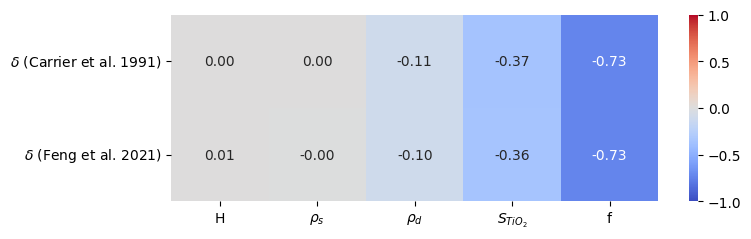

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


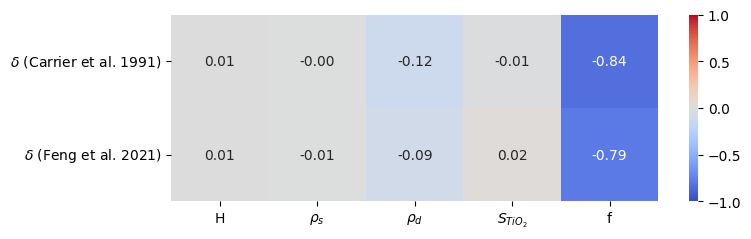

In [ ]:
freq_mrm = np.array([3, 7.8, 19.35, 37])
# freq = np.random.choice(freq_mrm,  Nmc)
freq = np.random.uniform(3, 37,  Nmc)

# =====================================================
# MAIN LOOP (FIXED)
# =====================================================

def compute_correlations(m_or_h):
    
    rows = []

    if m_or_h == "highland":
        S_TiO2 = np.random.uniform(0, 1, Nmc)
    elif m_or_h == "mare":
        S_TiO2 = sample_tio2(Nmc)
        
    for i_mc in range(Nmc):
            z_profile = z_vals_aux
            f = freq[i_mc]
            
            # -----------------------------------------
            # Extract ONE Monte Carlo sample
            # -----------------------------------------
            H_i = H[i_mc]
            rho_s_i = rho_s[i_mc]
            rho_d_i = rho_d[i_mc]
            S_i = S_TiO2[i_mc]

            # -----------------------------------------
            # Build FULL DEPTH PROFILE (Nz)
            # -----------------------------------------
            rho_profile = rho_effective_carlos_new2(
                z_profile,
                H=H_i,
                rho_s=rho_s_i,
                rho_d=rho_d_i
            )

            eps_profile = dielectric_constant_regolith(rho_profile)

            # -----------------------------------------
            # Carrier model
            # -----------------------------------------
            tan_car = loss_tangent_carrier_1991(rho_profile, S_i)

            delta_car = penetration_depth(
                z_profile,
                delta_z,
                eps_profile,
                tan_car,
                f
            )

            rows.append({
                "model": "Carrier et al. (1991)\n& MRM Frequencies",
                "H": H_i,
                r"$\rho_s$": rho_s_i,
                r"$\rho_d$": rho_d_i,
                r"$S_{TiO_2}$": S_i,
                "f": f,
                r"$\delta$": delta_car
            })

            # -----------------------------------------
            # Feng model
            # -----------------------------------------
            if m_or_h == "highland":
                tan_feng = loss_tangent_feng_2021_highland(rho_profile, f)
            elif m_or_h == "mare":
                tan_feng = loss_tangent_feng_2021_mare(rho_profile, f, S_i)

            delta_feng = penetration_depth(
                z_profile,
                delta_z,
                eps_profile,
                tan_feng,
                f
            )

            rows.append({
                "model": "Feng et al. (2021)\n& MRM Frequencies",
                "H": H_i,
                r"$\rho_s$": rho_s_i,
                r"$\rho_d$": rho_d_i,
                r"$S_{TiO_2}$": S_i,
                "f": f,
                r"$\delta$": delta_feng
            })

    df = pd.DataFrame(rows)

    # =====================================================
    # CORRELATION
    # =====================================================
    features = ["H", r"$\rho_s$", r"$\rho_d$", r"$S_{TiO_2}$", "f"]

    corr_matrix = pd.DataFrame({
        r"$\delta$" + " (Carrier et al. 1991)":
            df[df["model"] == "Carrier et al. (1991)\n& MRM Frequencies"]
            .corr(numeric_only=True).loc[features, r"$\delta$"],

        r"$\delta$" + " (Feng et al. 2021)":
            df[df["model"] == "Feng et al. (2021)\n& MRM Frequencies"]
            .corr(numeric_only=True).loc[features, r"$\delta$"],
    }).T

    # =====================================================
    # PLOT
    # =====================================================
    plt.figure(figsize=(8, 2.5))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        fmt=".2f"
    )

    plt.tight_layout()

    plt.show()
    
    return corr_matrix

corr_mare = compute_correlations("mare")
corr_highland = compute_correlations("highland")

In [137]:
def run_model(m_or_h,freq_list, z_vals_aux):
    
    if m_or_h == "highland":
        S_TiO2 = np.random.uniform(0, 1, Nmc)
    elif m_or_h == "mare":
        S_TiO2 = sample_tio2(Nmc)
    
    z_max = z_vals_aux[-1]

    mean_car, min_car, max_car = [], [], []
    mean_fen, min_fen, max_fen = [], [], []

    for f in freq_list:

        car_vals = []
        fen_vals = []

        for i in range(Nmc):

            rho = rho_effective_carlos_new2(z_vals_aux, H=H[i], rho_s = rho_s[i], rho_d = rho_d[i])
            eps = dielectric_constant_regolith(rho)

            # Carrier
            tan_car = loss_tangent_carrier_1991(rho, S_TiO2[i])
            car_vals.append(penetration_depth(z_vals_aux, delta_z, eps, tan_car, f))

            # Feng
            if m_or_h == "mare":
                tan_fen = loss_tangent_feng_2021_mare(rho, f, S_TiO2[i])
            elif m_or_h == "highland":
                tan_fen = loss_tangent_feng_2021_highland(rho, f)
            fen_vals.append(penetration_depth(z_vals_aux, delta_z, eps, tan_fen, f))

        # stats
        mean_car.append(np.mean(car_vals))
        min_car.append(np.min(car_vals))
        max_car.append(np.max(car_vals))

        mean_fen.append(np.mean(fen_vals))
        min_fen.append(np.min(fen_vals))
        max_fen.append(np.max(fen_vals))

    return (mean_car, min_car, max_car,mean_fen, min_fen, max_fen)

# =====================================================
# RUN CASES
# =====================================================

car_mrm_mare = run_model("mare", freq_mrm, z_vals_aux)
car_mrm_highland = run_model("highland", freq_mrm, z_vals_aux)

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


In [138]:
def barplot(ax, freqs, car, fen, ylim, Feng=True): 
    x = np.arange(len(freqs)) 
    width = 0.35 
    car_mean, car_min, car_max = map(np.array, car) 
    fen_mean, fen_min, fen_max = map(np.array, fen) 
    
    if Feng: # --- Carrier bars 
        ax.bar( x - width/2, car_max - car_min, bottom=car_min, width=width, alpha=0.5, label="Loss tangent from Carrier et al. (1991)", color="tab:blue" ) 
        # --- Carrier median markers 
        ax.scatter( x - width/2, car_mean, marker="x", color="tab:blue", s=60, zorder=3, label="Median value" ) 
        # # --- Carrier labels 
        for xi, yi in zip(x, car_mean):  
            if yi < 29:
                label = rf"$\sim${yi:.1f} m" if yi < 10 else rf"$\sim${yi:.0f} m"
                ax.text( xi, yi + 0.5, label, ha="right", va="bottom", fontsize=12, color="tab:blue" ) 
            else:
                label = rf"$\sim30$ m" 
                ax.text( xi, yi - 10, label, ha="right", va="bottom", fontsize=12, color="tab:blue" )
            
        # --- Feng bars 
        ax.bar( x + width/2, fen_max - fen_min, bottom=fen_min, width=width, alpha=0.5, label="Loss tangent from Feng et al. (2021)", color="tab:orange" ) 
        # --- Feng median markers 
        ax.scatter( x + width/2, fen_mean, marker="x", color="tab:orange", s=60, zorder=3 ) 
        # --- Feng labels 
        for xi, yi in zip(x + width/2, fen_mean):  
            if yi < 29:
                label = rf"$\sim${yi:.1f} m" if yi < 10 else rf"$\sim${yi:.0f} m"
                ax.text( xi, yi + 0.75, label, ha="center", va="bottom", fontsize=12, color="tab:orange" ) 
            else:
                label = rf"> 20 m" 
                ax.text( xi, yi - 10, label, ha="center", va="bottom", fontsize=12, color="tab:orange" ) 
    
    else: 
        ax.bar( x, car_max - car_min, bottom=car_min, width=width, alpha=0.5, label="Loss tangent from Carrier et al. (1991)", color="tab:blue" ) 
        ax.scatter( x, car_mean, marker="x", color="tab:blue", s=60, zorder=3, label="Median value" ) 
        
        # --- Labels (single case) 
        for xi, yi in zip(x, car_mean): 
            label = rf"$\sim${yi:.1f} m" if yi < 10 else rf"$\sim${yi:.0f} m" 
            ax.text( xi, yi + 0.75, label, ha="center", va="bottom", fontsize=12, color="tab:blue" ) 
    
    ax.set_xticks(x)
    ax.set_xticklabels(freqs)
    ax.tick_params(labelsize = 14)
    ax.set_xlabel("Frequency (GHz)", fontsize = 16)
    ax.set_ylabel("Penetration depth (m)", fontsize = 16)
    ax.grid(alpha=0.3)
    ax.legend(fontsize = 12)
    ax.set_ylim(ylim)

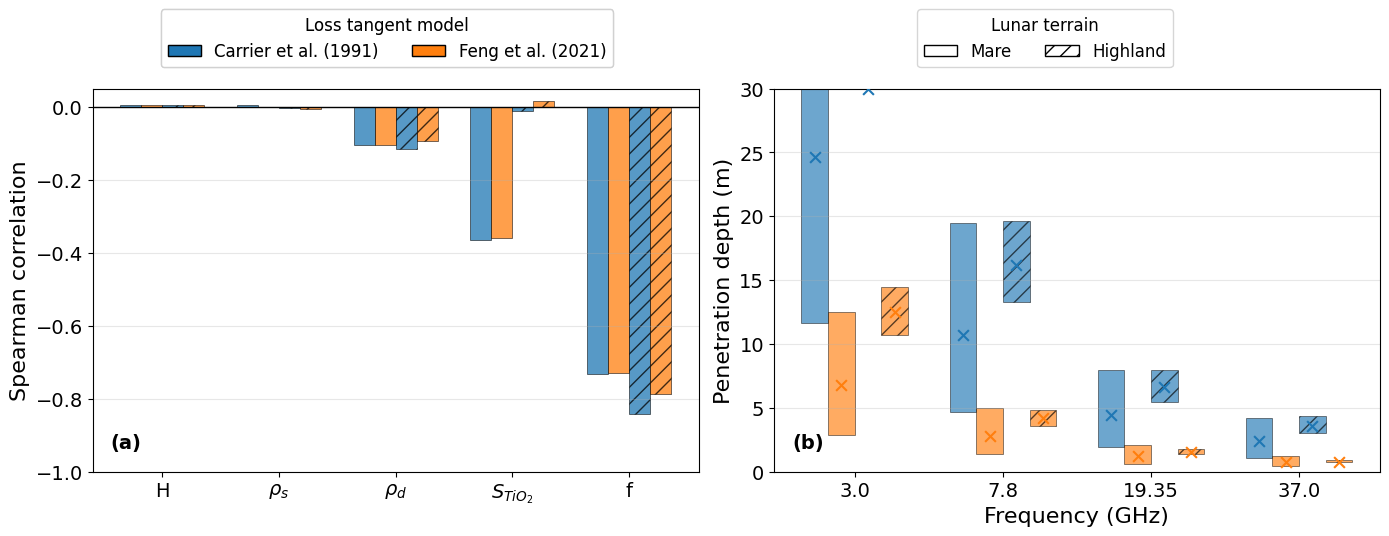

In [ ]:
# =====================================================
# FIGURE
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)


# =====================================================
# (a) CORRELATION COEFFICIENTS
# =====================================================

ax = axes[0]


# parameters
params = [
    "H",
    r"$\rho_s$",
    r"$\rho_d$",
    r"$S_{TiO_2}$",
    "f"
]


x = np.arange(len(params))

width = 0.18


cases_corr = [

    (
        "Mare",
        "Carrier",
        corr_mare.loc[
            r"$\delta$ (Carrier et al. 1991)",
            params
        ],
        "tab:blue",
        ""
    ),

    (
        "Mare",
        "Feng",
        corr_mare.loc[
            r"$\delta$ (Feng et al. 2021)",
            params
        ],
        "tab:orange",
        ""
    ),

    (
        "Highland",
        "Carrier",
        corr_highland.loc[
            r"$\delta$ (Carrier et al. 1991)",
            params
        ],
        "tab:blue",
        "//"
    ),

    (
        "Highland",
        "Feng",
        corr_highland.loc[
            r"$\delta$ (Feng et al. 2021)",
            params
        ],
        "tab:orange",
        "//"
    )

]


offsets = [
    -1.5*width,
    -0.5*width,
    0.5*width,
    1.5*width
]


for offset, (terrain, model, values, color, hatch) in zip(
    offsets,
    cases_corr
):

    ax.bar(
        x + offset,
        values,
        width=width,
        color=color,
        alpha=0.75,
        hatch=hatch,
        edgecolor="black",
        linewidth=0.5,
        label=f"{terrain}, {model}"
    )


ax.axhline(
    0,
    color="black",
    linewidth=1
)


ax.set_xticks(x)

ax.set_xticklabels(
    params,
    fontsize=14
)

ax.set_ylabel(
    "Spearman correlation",
    fontsize=16
)


ax.set_ylim(
    -1,
    0.05
)


ax.grid(
    alpha=0.3,
    axis="y"
)


ax.text(
    0.03,
    0.1,
    "(a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)
ax.tick_params(labelsize = 14)




# =====================================================
# (b) PENETRATION DEPTH
# =====================================================

ax = axes[1]


def add_penetration_bars(
    ax,
    x,
    data,
    width,
    color,
    hatch,
    label
):

    mean, low, high = map(np.array, data)

    ax.bar(
        x,
        high-low,
        bottom=low,
        width=width,
        color=color,
        alpha=0.65,
        hatch=hatch,
        edgecolor="black",
        linewidth=0.5,
        label=label
    )
    ax.tick_params(labelsize = 14)


    ax.scatter(
        x,
        mean,
        color=color,
        marker="x",
        s=60,
        zorder=3
    )



freq_x = np.arange(len(freq_mrm))

width = 0.18


cases_depth = [

    (
        "Mare",
        "Carrier",
        car_mrm_mare[:3],
        "tab:blue",
        ""
    ),

    (
        "Mare",
        "Feng",
        car_mrm_mare[3:],
        "tab:orange",
        ""
    ),

    (
        "Highland",
        "Carrier",
        car_mrm_highland[:3],
        "tab:blue",
        "//"
    ),

    (
        "Highland",
        "Feng",
        car_mrm_highland[3:],
        "tab:orange",
        "//"
    )

]


offsets = [
    -1.5*width,
    -0.5*width,
    0.5*width,
    1.5*width
]


for offset, (terrain, model, data, color, hatch) in zip(
    offsets,
    cases_depth
):

    add_penetration_bars(
        ax,
        freq_x + offset,
        data,
        width,
        color,
        hatch,
        f"{terrain}, {model}"
    )


ax.set_xticks(
    freq_x
)

ax.set_xticklabels(
    freq_mrm,
    fontsize=13
)

ax.tick_params(labelsize = 14)


ax.set_xlabel(
    "Frequency (GHz)",
    fontsize=16
)


ax.set_ylabel(
    "Penetration depth (m)",
    fontsize=16
)


ax.set_ylim(
    0,
    30
)


ax.grid(
    alpha=0.3,
    axis="y"
)


ax.text(
    0.03,
    0.1,
    "(b)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)



from matplotlib.patches import Patch


# -----------------------------
# Loss tangent model (colors)
# -----------------------------

loss_handles = [
    Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label="Carrier et al. (1991)"
    ),
    Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label="Feng et al. (2021)"
    )
]


# -----------------------------
# Lunar terrain (hatches)
# -----------------------------

terrain_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="",
        label="Mare"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="//",
        label="Highland"
    )
]


legend1 = fig.legend(
    handles=loss_handles,
    loc="upper center",
    bbox_to_anchor=(0.28, 1.08),
    ncols=2,
    fontsize=12,
    frameon=True,
    title="Loss tangent model",
    title_fontsize=12
)


legend2 = fig.legend(
    handles=terrain_handles,
    loc="upper center",
    bbox_to_anchor=(0.75, 1.08),
    ncols=2,
    fontsize=12,
    frameon=True,
    title="Lunar terrain",
    title_fontsize=12
)


# keep both legends
fig.add_artist(legend1)



plt.tight_layout(rect=[0,0,1,0.95])


# =====================================================
# SAVE
# =====================================================

plt.savefig(
    os.path.join(
        save_folder,
        "correlation_penetration_combined.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

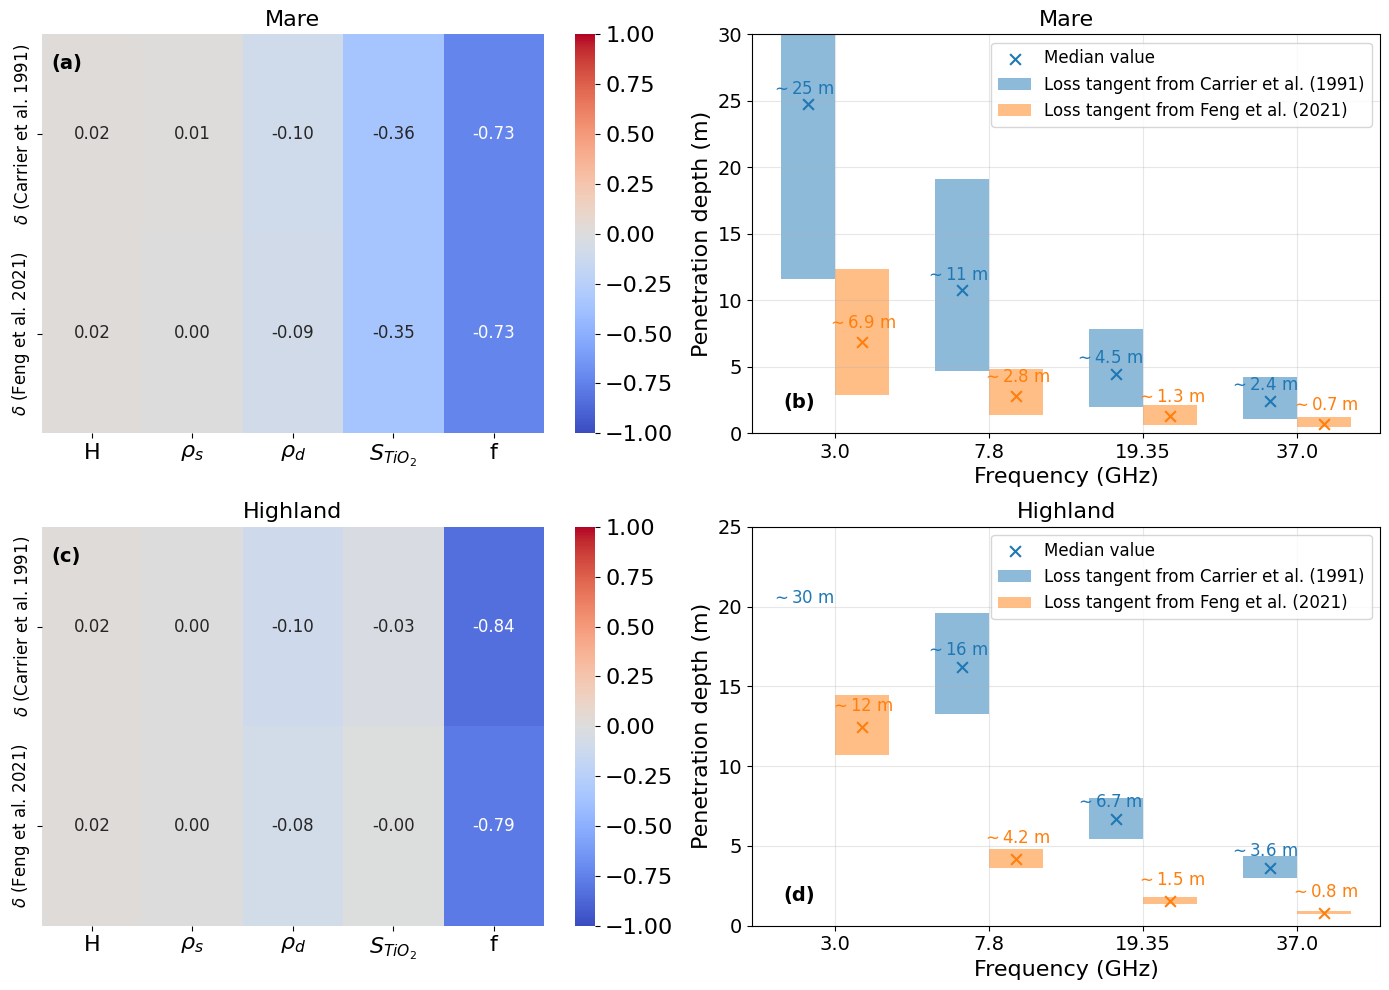

In [34]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14,10),
    gridspec_kw={"width_ratios":[1,1]}
)

# =====================================================
# MARE HEATMAP
# =====================================================

hm = sns.heatmap(
    corr_mare,
    annot=True,
    annot_kws={"fontsize": 12},
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[0,0]
)

# Row and column labels
axes[0,0].tick_params(axis="x", labelsize=16)
axes[0,0].tick_params(axis="y", labelsize=12)

# Colorbar tick labels
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

axes[0,0].tick_params(axis="y", labelrotation=90)


axes[0,0].set_title("Mare", fontsize = 16)
axes[0,0].text(
    0.02,0.95,"(a)",
    transform=axes[0,0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# =====================================================
# MARE PENETRATION DEPTH
# =====================================================

barplot(
    axes[0,1],
    freq_mrm,
    car_mrm_mare[:3],
    car_mrm_mare[3:],
    ylim=[0,30],
    Feng=True
)

axes[0,1].set_title("Mare", fontsize = 16)

axes[0,1].text(
    0.05,0.1,"(b)",
    transform=axes[0,1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# =====================================================
# HIGHLAND HEATMAP
# =====================================================

hm = sns.heatmap(
    corr_highland,
    annot=True,
    annot_kws={"fontsize": 12},
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[1,0]
)

# Row and column labels
axes[1,0].tick_params(axis="x", labelsize=16)
axes[1,0].tick_params(axis="y", labelsize=12)

# Colorbar tick labels
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

axes[1,0].tick_params(axis="y", labelrotation=90)
axes[1,0].set_title("Highland", fontsize = 16)

axes[1,0].text(
    0.02,0.95,"(c)",
    transform=axes[1,0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# =====================================================
# HIGHLAND PENETRATION DEPTH
# =====================================================

barplot(
    axes[1,1],
    freq_mrm,
    car_mrm_highland[:3],
    car_mrm_highland[3:],
    ylim=[0,25],
    Feng=True
)

axes[1,1].set_title("Highland", fontsize = 16)

axes[1,1].text(
    0.05,0.1,"(d)",
    transform=axes[1,1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        save_folder,
        "penetration_depth_combined.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Check changes with frequency

In [35]:
freq = np.linspace(3,37,100)

def compute_corr_vs_freq(m_or_h):

    features = ["H", "rho_s", "rho_d", "S_TiO2"]

    results = []

    # -------------------------
    # Sample TiO2 ONCE
    # -------------------------
    if m_or_h == "highland":
        S_TiO2 = np.random.uniform(0, 1, Nmc)
    else:
        S_TiO2 = sample_tio2(Nmc)

    # =====================================================
    # LOOP OVER FREQUENCY
    # =====================================================
    for f in freq:

        # Store MC results for this frequency
        data_carrier = {key: [] for key in features + ["pd"]}
        data_feng    = {key: [] for key in features + ["pd"]}

        for i_mc in range(Nmc):

            H_i = H[i_mc]
            rho_s_i = rho_s[i_mc]
            rho_d_i = rho_d[i_mc]
            S_i = S_TiO2[i_mc]

            z_profile = z_vals_aux

            rho_profile = rho_effective_carlos_new2(
                z_profile,
                H=H_i,
                rho_s=rho_s_i,
                rho_d=rho_d_i
            )

            eps_profile = dielectric_constant_regolith(rho_profile)

            # =========================
            # Carrier
            # =========================
            tan_car = loss_tangent_carrier_1991(rho_profile, S_i)

            delta_car = penetration_depth(
                z_profile, delta_z, eps_profile, tan_car, f
            )

            # =========================
            # Feng
            # =========================
            if m_or_h == "highland":
                tan_feng = loss_tangent_feng_2021_highland(rho_profile, f)
            else:
                tan_feng = loss_tangent_feng_2021_mare(rho_profile, f, S_i)

            delta_feng = penetration_depth(
                z_profile, delta_z, eps_profile, tan_feng, f
            )

            # Store values
            for key, val in zip(features, [H_i, rho_s_i, rho_d_i, S_i]):
                data_carrier[key].append(val)
                data_feng[key].append(val)

            data_carrier["pd"].append(delta_car)
            data_feng["pd"].append(delta_feng)

        # Convert to DataFrame
        df_c = pd.DataFrame(data_carrier)
        df_f = pd.DataFrame(data_feng)

        # Spearman correlation
        corr_c = df_c.corr(method="spearman")
        corr_f = df_f.corr(method="spearman")

        # Store results in long format
        for var in features:
            results.append({
                "f": f,
                "model": "Carrier et al. (1991)",
                "variable": var,
                "corr": corr_c.loc["pd", var]
            })

            results.append({
                "f": f,
                "model": "Feng et al. (2021)",
                "variable": var,
                "corr": corr_f.loc["pd", var]
            })

    return pd.DataFrame(results)
        

def plot_corr_vs_freq(df_corr, title):

    plt.figure(figsize=(7,5))

    linestyles = {
        "Carrier et al. (1991)": "-",
        "Feng et al. (2021)": "--"
    }

    colors_map = {
        "H": colors[0],
        "rho_s": colors[1],
        "rho_d": colors[2],
        "S_TiO2": colors[3]
    }

    # =========================
    # Plot lines
    # =========================
    for (model, var), group in df_corr.groupby(["model", "variable"]):

        group = group.sort_values("f")

        plt.plot(
            group["f"],
            group["corr"],  # or y if smoothed
            linestyle=linestyles[model],
            color=colors_map[var],
            linewidth=2
        )

    plt.xlabel("Frequency [GHz]", fontsize=16)
    plt.ylabel("Spearman correlation", fontsize=16)
    plt.title(title)
    plt.ylim([-1, 1])

    plt.xticks(np.arange(5, 36, 5), fontsize=14)
    plt.yticks(fontsize=14)

    # =========================
    # Legend 1: parameters (colors)
    # =========================
    param_handles = [
        Line2D([0], [0], color=colors_map[var], lw=2)
        for var in colors_map
    ]

    label_map = {
        "H": r"$H$",
        "rho_s": r"$\rho_s$",
        "rho_d": r"$\rho_d$",
        "S_TiO2": r"$S_{TiO_2}$"
    }

    text_label = r"z_{\delta}"

    param_labels = [
        rf"$r({text_label}, {label_map[var][1:-1]})$"
        for var in colors_map
    ]

    legend1 = plt.legend(
        param_handles,
        param_labels,
        title="Parameter",
        title_fontsize=14,
        loc="upper right",
        fontsize=12
    )

    plt.gca().add_artist(legend1)

    # =========================
    # Legend 2: models (linestyles)
    # =========================
    model_handles = [
        Line2D([0], [0], color="black", linestyle=linestyles[m], lw=2)
        for m in linestyles
    ]

    plt.legend(
        model_handles,
        list(linestyles.keys()),
        title="Loss tangent model",
        title_fontsize=14,
        loc="upper left",
        fontsize=12
    )

    plt.xlim([3, 37])
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [36]:
df_corr_mare = compute_corr_vs_freq("mare")
df_corr_high = compute_corr_vs_freq("highland")

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


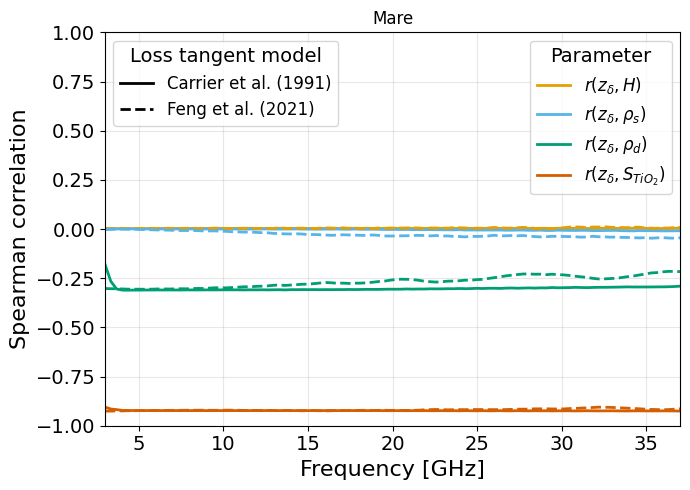

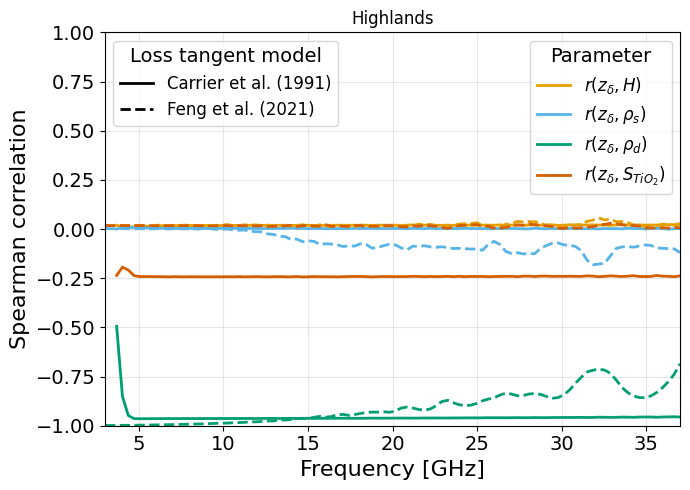

In [37]:
plot_corr_vs_freq(df_corr_mare, "Mare")
plot_corr_vs_freq(df_corr_high, "Highlands")

## Thermal Inertia

In [24]:
cases = ["dry", "icy"]
corr_all_VM = {}


# ==========================================================
# LOOP OVER MODELS
# ==========================================================

for case in cases:

    if case == "dry":
        
        corr = {
            "H": [],
            "Kd": [],
            "Ks": [],
            "Chi": [],
            "rho_s": [],
            "rho_d": []}
        
        for z in z_vals:
                
            T = get_T_dry(z, T_deep_vec)
            
            rho = rho_effective_carlos_new2(
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d)
            
            cp = cp_dry_Hayne_2017(T)
            
            K = K_Hayne_2017(T, np.full(Nmc, z), H = H, Ks = Ks, Kd = Kd, Chi = Chi)
            
            inertia = np.sqrt(K*cp*rho)
            
            df = pd.DataFrame({
                "H": H,
                "Kd": Kd,
                "Ks": Ks,
                "Chi": Chi,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "I": inertia

            })


            c = df.corr(
                method="spearman"
            )


            for param in corr.keys():

                corr[param].append(
                    c.loc["I", param]
                )
        
    else:
            
        corr = {
            "H": [],
            "Kd": [],
            "Ks": [],
            "Chi": [],
            "rho_s": [],
            "rho_d": [],
            "wt": [],
            "z_start": [],
            "z_end": [],
            "delta": [],
            "rho_basalt": [],
            "k_solid": []}
        
        T = T_icy
        
        for z in z_vals:

            rho = rho_effective_carlos_new2(
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d,
                wt_max=wt_max,
                z_start=z_start,
                z_end=z_end,
                dz=dz
            )

            Cr = get_Cr(
                rho,
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d
            )

            phi = porosity(
                rho,
                rho_basalt=rho_basalt
            )

            PFF = pore_filling_fraction(
                np.full(Nmc, z),
                Cr,
                phi,
                H=H,
                rho_s=rho_s,
                rho_d=rho_d
            )


            cp = cp_effective_carlos(T, rhos = rho, phi = phi, PFF = PFF)
            # -------------------------
            # Conductivity
            # -------------------------

            K = k_eff(
                T,
                np.full(Nmc, z),
                phi=phi,
                PFF=PFF,
                H=H,
                Kd=Kd,
                Ks=Ks,
                Chi=Chi
            )
            
            inertia = np.sqrt(K*cp*rho)
            
            df = pd.DataFrame({
                "H": H,
                "Kd": Kd,
                "Ks": Ks,
                "Chi": Chi,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "wt": wt_max,
                "z_start": z_start,
                "z_end": z_end,
                "delta": dz,
                "rho_basalt": rho_basalt,
                "k_solid": k_solid,
                "I": inertia

            })


            c = df.corr(
                method="spearman"
            )


            for param in corr.keys():

                corr[param].append(
                    c.loc["I", param]
                )

    corr_all_VM[case] = {
        key: np.array(value)
        for key, value in corr.items()
    }
    
    
corr_all_GB = {}


# ==========================================================
# LOOP OVER MODELS
# ==========================================================

for case in cases:

    if case == "dry":
        
        corr = {
            "H": [],
            "Kd": [],
            "Ks": [],
            "Chi": [],
            "rho_s": [],
            "rho_d": []}
        
        for z in z_vals:
                
            T = get_T_dry(z, T_deep_vec)
            
            rho = rho_effective_carlos_new2(
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d)
            
            cp = cp_dry_Hayne_2017(T)
            
            K = K_Hayne_2017(T, np.full(Nmc, z), H = H, Ks = Ks, Kd = Kd, Chi = Chi)
            
            inertia = np.sqrt(K*cp*rho)
            
            df = pd.DataFrame({
                "H": H,
                "Kd": Kd,
                "Ks": Ks,
                "Chi": Chi,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "I": inertia

            })


            c = df.corr(
                method="spearman"
            )


            for param in corr.keys():

                corr[param].append(
                    c.loc["I", param]
                )
        
    else:
            
        corr = {
            "H": [],
            "Kd": [],
            "Ks": [],
            "Chi": [],
            "rho_s": [],
            "rho_d": [],
            "wt": [],
            "z_start": [],
            "z_end": [],
            "delta": [],
            "rho_basalt": [],
            "k_solid": []}
        
        T = T_icy
        
        for z in z_vals:

            rho = rho_effective_carlos_new2(
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d,
                wt_max=wt_max,
                z_start=z_start,
                z_end=z_end,
                dz=dz
            )

            Cr = get_Cr(
                rho,
                np.full(Nmc, z),
                H=H,
                rho_s=rho_s,
                rho_d=rho_d
            )

            phi = porosity(
                rho,
                rho_basalt=rho_basalt
            )

            PFF = pore_filling_fraction(
                np.full(Nmc, z),
                Cr,
                phi,
                H=H,
                rho_s=rho_s,
                rho_d=rho_d
            )


            cp = cp_effective_carlos(T, rhos = rho, phi = phi, PFF = PFF)
            # -------------------------
            # Conductivity
            # -------------------------

            K = k_eff_Mellon_1997_new(
                T,
                np.full(Nmc, z),
                phi=phi,
                PFF=PFF,
                H=H,
                Kd=Kd,
                Ks=Ks,
                Chi=Chi,
                k_solid = k_solid
            )
            
            inertia = np.sqrt(K*cp*rho)
            
            df = pd.DataFrame({
                "H": H,
                "Kd": Kd,
                "Ks": Ks,
                "Chi": Chi,
                "rho_s": rho_s,
                "rho_d": rho_d,
                "wt": wt_max,
                "z_start": z_start,
                "z_end": z_end,
                "delta": dz,
                "rho_basalt": rho_basalt,
                "k_solid": k_solid,
                "I": inertia

            })


            c = df.corr(
                method="spearman"
            )


            for param in corr.keys():

                corr[param].append(
                    c.loc["I", param]
                )

    corr_all_GB[case] = {
        key: np.array(value)
        for key, value in corr.items()
    }

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


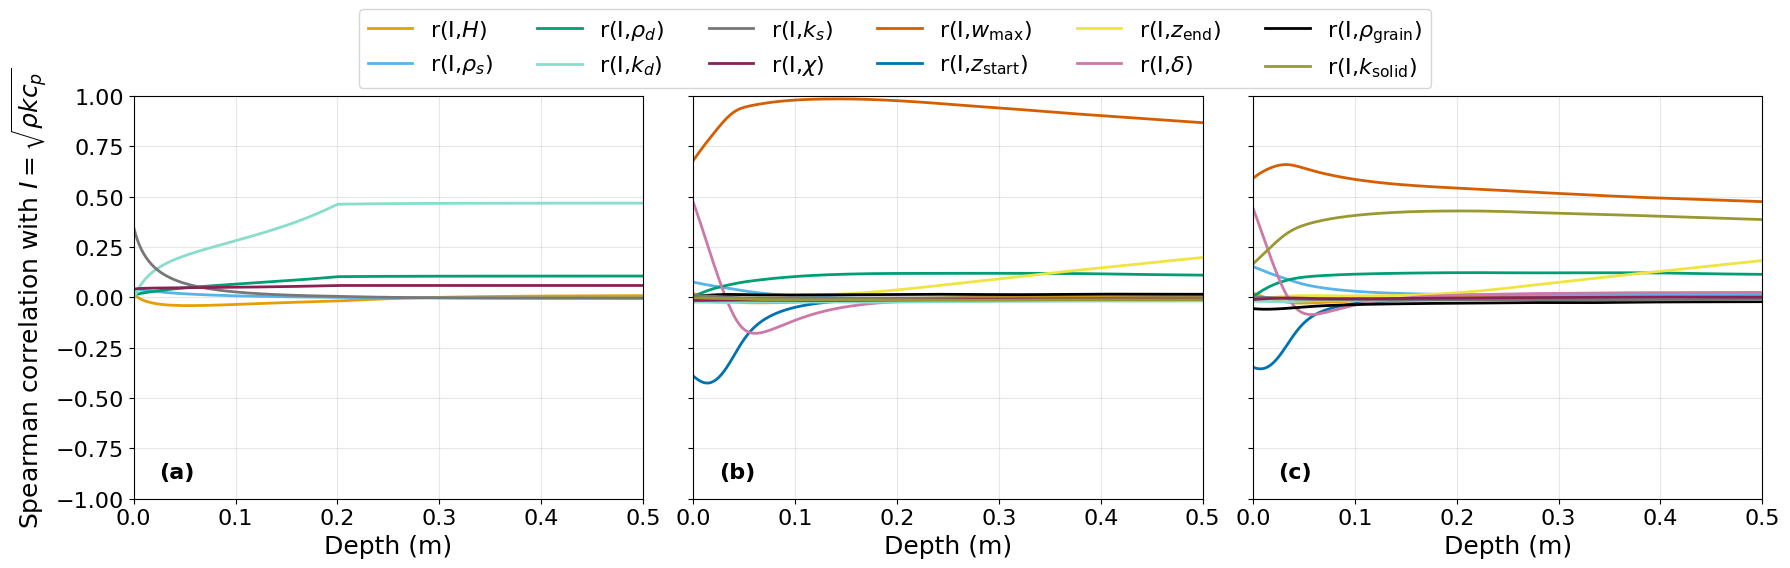

In [25]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5),
    sharey=True
)


plot_cases = [
    ("Dry", corr_all_VM["dry"]),
    ("Icy - VM", corr_all_VM["icy"]),
    ("Icy - GB", corr_all_GB["icy"])
]


plot_params = {
    "H": r"$H$",
    "rho_s": r"$\rho_s$",
    "rho_d": r"$\rho_d$",
    "wt": r"$w_{\max}$",
    "z_start": r"$z_{\mathrm{start}}$",
    "z_end": r"$z_{\mathrm{end}}$",
    "delta": r"$\delta$",
    "rho_basalt": r"$\rho_{\mathrm{grain}}$",
    "Kd": r"$k_d$",
    "Ks": r"$k_s$",
    "Chi": r"$\chi$",
    "k_solid": r"$k_{\mathrm{solid}}$"
}


# -----------------------------------------------------
# Fixed color assignment
# -----------------------------------------------------

param_colors = {
    param: colors[i]
    for i, param in enumerate(plot_params.keys())
}



panel_labels = [
    "(a)",
    "(b)",
    "(c)"
]


# -----------------------------------------------------
# Plot
# -----------------------------------------------------

for ax, (title, corr_case), panel in zip(
    axes,
    plot_cases,
    panel_labels
):


    for param, label in plot_params.items():

        if param not in corr_case:
            continue


        ax.plot(
            z_vals,
            corr_case[param],
            linewidth=2,
            color=param_colors[param],
            label=f"r(I,{label})"
        )


    ax.set_xlim(
        0,
        0.5
    )


    ax.set_ylim(
        -1,
        1
    )


    ax.grid(
        alpha=0.3
    )


    ax.set_xlabel(
        "Depth (m)",
        fontsize=18
    )


    ax.tick_params(
        labelsize=16
    )


    ax.text(
        0.05,
        0.05,
        panel,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold"
    )


axes[0].set_ylabel(
    r"Spearman correlation with $I=\sqrt{\rho k c_p}$",
    fontsize=18
)



# -----------------------------------------------------
# One common legend
# -----------------------------------------------------

handles = []
labels = []


for ax in axes:

    h, l = ax.get_legend_handles_labels()

    for handle, label in zip(h,l):

        if label not in labels:
            handles.append(handle)
            labels.append(label)



fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5,1.15),
    ncols=6,
    fontsize=16,
    frameon=True
)



plt.tight_layout()


save_folder = os.path.join(
    root_folder,
    "Icy",
    "inertia"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "correlation_inertia_VM_GB.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/JGR_LunarRegolithPropertiesVariability/Regolith1D_JGR.py:472: RuntimeWarning: overflow encountered in exp
  off = 1 / (1 + np.exp(-(z - z_end)/dz))


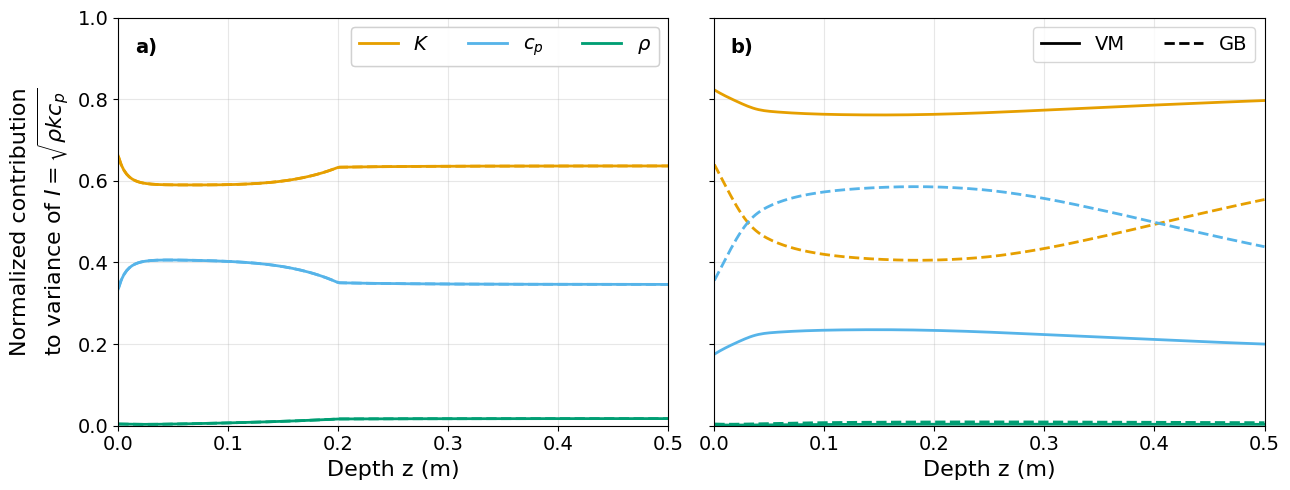

In [26]:
# ==========================================================
# NORMALIZED VARIANCE CONTRIBUTION TO THERMAL INERTIA
# ==========================================================

S_K = {}
S_cp = {}
S_rho = {}

conductivity_models = ["VM", "GB"]

for model in conductivity_models:

    S_K[model] = {}
    S_cp[model] = {}
    S_rho[model] = {}

    for case in cases:

        S_K[model][case] = np.zeros(Nz)
        S_cp[model][case] = np.zeros(Nz)
        S_rho[model][case] = np.zeros(Nz)


        for iz, z in enumerate(z_vals):


            # ==================================================
            # COMPUTE rho, cp
            # ==================================================

            if case == "dry":

                T = get_T_dry(
                    z,
                    T_deep_vec
                )


                rho = rho_effective_carlos_new2(
                    np.full(Nmc, z),
                    H=H,
                    rho_s=rho_s,
                    rho_d=rho_d
                )


                cp = cp_dry_Hayne_2017(T)


                # dry conductivity is the same
                K = K_Hayne_2017(
                    T,
                    np.full(Nmc, z),
                    H=H,
                    Ks=Ks,
                    Kd=Kd,
                    Chi=Chi
                )


            else:

                T = T_icy


                rho = rho_effective_carlos_new2(
                    np.full(Nmc, z),
                    H=H,
                    rho_s=rho_s,
                    rho_d=rho_d,
                    wt_max=wt_max,
                    z_start=z_start,
                    z_end=z_end,
                    dz=dz
                )


                Cr = get_Cr(
                    rho,
                    np.full(Nmc, z),
                    H=H,
                    rho_s=rho_s,
                    rho_d=rho_d
                )


                phi = porosity(
                    rho,
                    rho_basalt=rho_basalt
                )


                PFF = pore_filling_fraction(
                    np.full(Nmc, z),
                    Cr,
                    phi,
                    H=H,
                    rho_s=rho_s,
                    rho_d=rho_d
                )


                cp = cp_effective_carlos(
                    T,
                    rhos=rho,
                    phi=phi,
                    PFF=PFF
                )


                # ==================================================
                # CHOOSE CONDUCTIVITY MODEL
                # ==================================================

                if model == "VM":

                    K = k_eff(
                        T,
                        np.full(Nmc, z),
                        phi=phi,
                        PFF=PFF,
                        H=H,
                        Kd=Kd,
                        Ks=Ks,
                        Chi=Chi
                    )


                elif model == "GB":

                    K = k_eff_Mellon_1997_new(
                        T,
                        np.full(Nmc, z),
                        phi=phi,
                        PFF=PFF,
                        H=H,
                        Kd=Kd,
                        Ks=Ks,
                        Chi=Chi,
                        k_solid=k_solid
                    )



            # ==================================================
            # OAT VARIANCE DECOMPOSITION
            # ==================================================

            K_bar = np.mean(K)
            cp_bar = np.mean(cp)
            rho_bar = np.mean(rho)


            Var_K = np.var(
                np.sqrt(K * cp_bar * rho_bar)
            )


            Var_cp = np.var(
                np.sqrt(K_bar * cp * rho_bar)
            )


            Var_rho = np.var(
                np.sqrt(K_bar * cp_bar * rho)
            )


            denom = (
                Var_K
                + Var_cp
                + Var_rho
                + 1e-12
            )


            S_K[model][case][iz] = Var_K / denom
            S_cp[model][case][iz] = Var_cp / denom
            S_rho[model][case][iz] = Var_rho / denom



# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,5),
    sharey=True
)


colors_var = {
    "K": colors[0],
    "cp": colors[1],
    "rho": colors[2]
}


linestyles = {
    "VM": "-",
    "GB": "--"
}


panel_labels = ["a)", "b)"]


for ax, case, panel in zip(axes, cases, panel_labels):


    for model in conductivity_models:


        ls = linestyles[model]


        ax.plot(
            z_vals,
            S_K[model][case],
            linewidth=2,
            color=colors_var["K"],
            linestyle=ls
        )


        ax.plot(
            z_vals,
            S_cp[model][case],
            linewidth=2,
            color=colors_var["cp"],
            linestyle=ls
        )


        ax.plot(
            z_vals,
            S_rho[model][case],
            linewidth=2,
            color=colors_var["rho"],
            linestyle=ls
        )


    ax.text(
        0.03,
        0.95,
        panel,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )


    ax.set_xlabel(
        "Depth z (m)",
        fontsize=16
    )


    ax.tick_params(
        axis="both",
        labelsize=14
    )


    ax.set_xlim(
        0,
        0.5
    )

    ax.set_ylim(
        0,
        1
    )


    ax.grid(alpha=0.3)



axes[0].set_ylabel(
    r"Normalized contribution" "\n"
    r"to variance of $I=\sqrt{\rho k c_p}$",
    fontsize=16
)



# ==========================================================
# TWO LEGENDS
# ==========================================================

from matplotlib.lines import Line2D


# colors legend
color_legend = [
    Line2D(
        [0],
        [0],
        color=colors_var[key],
        lw=2,
        label=label
    )
    for key, label in [
        ("K", r"$K$"),
        ("cp", r"$c_p$"),
        ("rho", r"$\rho$")
    ]
]


# linestyle legend
style_legend = [
    Line2D(
        [0],
        [0],
        color="black",
        lw=2,
        linestyle=linestyles[key],
        label=key
    )
    for key in ["VM", "GB"]
]


leg1 = axes[0].legend(
    handles=color_legend,
    fontsize=14,
    loc="upper right",
    ncols = 3
)


axes[0].add_artist(leg1)


axes[1].legend(
    handles=style_legend,
    fontsize=14,
    loc="upper right",
    ncols = 2
)


plt.tight_layout()


plt.savefig(
    os.path.join(save_folder, "var_inertia_models.pdf"),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Boundary Conditions

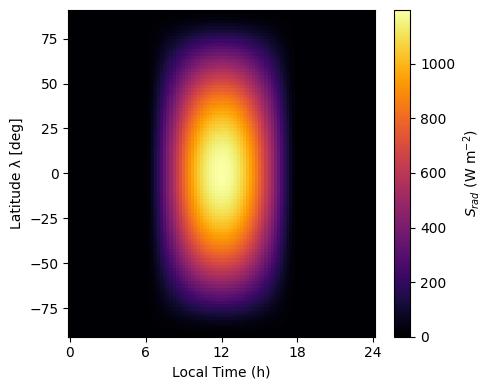

In [38]:
# -----------------------------
# CONSTANTS
# -----------------------------
S0 = 1361  # W/m^2

# -----------------------------
# GRID
# -----------------------------
time_vec = np.linspace(0, 24, 100)      # hours
lambda_vec = np.linspace(-90, 90, 100)  # latitude (deg)

T, L = np.meshgrid(time_vec, lambda_vec)

# -----------------------------
# STORAGE
# -----------------------------
Srad = np.zeros((len(lambda_vec), len(time_vec)))

# -----------------------------
# COMPUTE
# -----------------------------
theta = 0
s = 0

for i, lam_deg in enumerate(lambda_vec):

    lambda_rad = np.radians(lam_deg)

    for j, t_hr in enumerate(time_vec):

        t_sec = t_hr * 3600
        ci = cos_iota(t_sec, lambda_rad, theta, s)

        if ci > 0:
            Srad[i, j] = S0 * (1 - albedo_hayne_2017(np.arccos(ci))) * ci
        else:
            Srad[i, j] = 0.0

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(5, 4))

im = plt.pcolormesh(
    T,
    L,
    Srad,
    shading="auto",
    cmap="inferno"
)

plt.xlabel("Local Time (h)")
plt.xticks(np.linspace(0,24, 5))
plt.ylabel("Latitude λ [deg]")
# plt.title("Incoming Solar Radiation (Hayne 2017 Albedo)")

cbar = plt.colorbar(im)
cbar.set_label(r"$S_{rad}$ (W m$^{-2}$)")

plt.tight_layout()
save_folder = os.path.join(root_folder, "Dry", "BC")
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "incoming_day.pdf"))
plt.show()

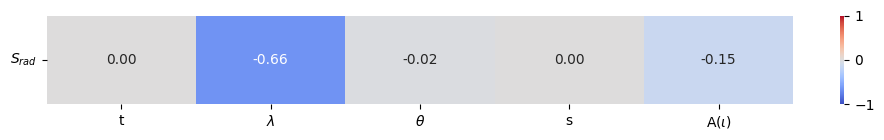

In [39]:
# =====================================================
# SAMPLE SIZE
# =====================================================

N = 10000
S0 = 1361

# =====================================================
# RANDOM INPUTS
# =====================================================

lambda_rad = np.random.uniform(0, np.pi/2, N)
theta      = np.random.uniform(0, np.pi/36, N)
s          = np.random.uniform(0, np.pi/36, N)

# One lunar day
t_step = np.random.uniform(6*3600, 18*3600, N)

# =====================================================
# ALBEDO MODELS
# =====================================================

albedo_models = [
    albedo_hayne_2017,
    albedo_yu_2025_highland,
    albedo_yu_2025_mare,
    albedo_vasavada_mare_2012,
    albedo_vasavada_highland_2012
]

albedo_index = np.random.randint(0, len(albedo_models), N)

# =====================================================
# OUTPUT
# =====================================================

ci_arr = np.zeros(N)
S_rad = np.zeros(N)

# =====================================================
# MONTE CARLO
# =====================================================

for i in range(N):
    
    ci = cos_iota(
        t_step[i],
        lambda_rad[i],
        theta[i],
        s[i]
    )

    ci_arr[i] = ci

    if ci > 0:

        alb = albedo_models[albedo_index[i]](np.arccos(ci))

        S_rad[i] = S0 * (1 - alb) * ci

    else:

        S_rad[i] = 0

# =====================================================
# DATAFRAME
# =====================================================

df = pd.DataFrame({
    "t": t_step,
    r"$\lambda$": lambda_rad,
    r"$\theta$": theta,
    "s": s,
    r"A($\iota$)": albedo_index,
    r"$S_{rad}$": S_rad
})

# =====================================================
# CORRELATION
# =====================================================

cols = [
    "t",
    r"$\lambda$",
    r"$\theta$",
    "s",
    r"A($\iota$)",
]

corr = df.corr(method="spearman").loc[[r"$S_{rad}$"], cols]

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,1.5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

# plt.title(r"Correlation of absorbed solar radiation $S_{rad}$ (during local daytime)")
plt.yticks(rotation=0)
plt.tight_layout()
save_folder = os.path.join(root_folder, "Dry", "BC")
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, "correlation_srad.pdf"))

plt.show()

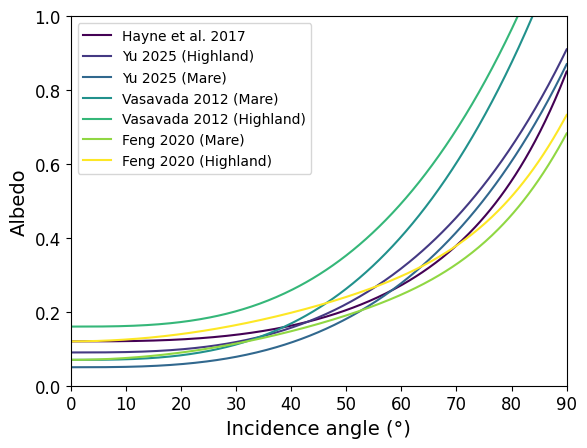

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Incidence angle range (0 to 90 degrees in radians)
iota = np.linspace(0, np.pi/2, 300)

plt.figure()

# Number of curves
n = 7
colors = plt.cm.viridis(np.linspace(0, 1, n))

plt.plot(np.rad2deg(iota), albedo_hayne_2017(iota),
         label="Hayne et al. 2017", color=colors[0])

plt.plot(np.rad2deg(iota), albedo_yu_2025_highland(iota),
         label="Yu 2025 (Highland)", color=colors[1])

plt.plot(np.rad2deg(iota), albedo_yu_2025_mare(iota),
         label="Yu 2025 (Mare)", color=colors[2])

plt.plot(np.rad2deg(iota), albedo_vasavada_mare_2012(iota),
         label="Vasavada 2012 (Mare)", color=colors[3])

plt.plot(np.rad2deg(iota), albedo_vasavada_highland_2012(iota),
         label="Vasavada 2012 (Highland)", color=colors[4])

plt.plot(np.rad2deg(iota), albedo_feng_2020_mare(iota),
         label="Feng 2020 (Mare)", color=colors[5])

plt.plot(np.rad2deg(iota), albedo_feng_2020_highland(iota),
         label="Feng 2020 (Highland)", color=colors[6])


plt.xlabel("Incidence angle (°)", fontsize=14)
plt.ylabel("Albedo", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim([0, 1])
plt.xlim([0, 90])

plt.legend()
# plt.savefig(os.path.join(fig_folder, "albedo.pdf"))
plt.savefig(os.path.join(save_folder, "albedo.pdf"))
plt.show()

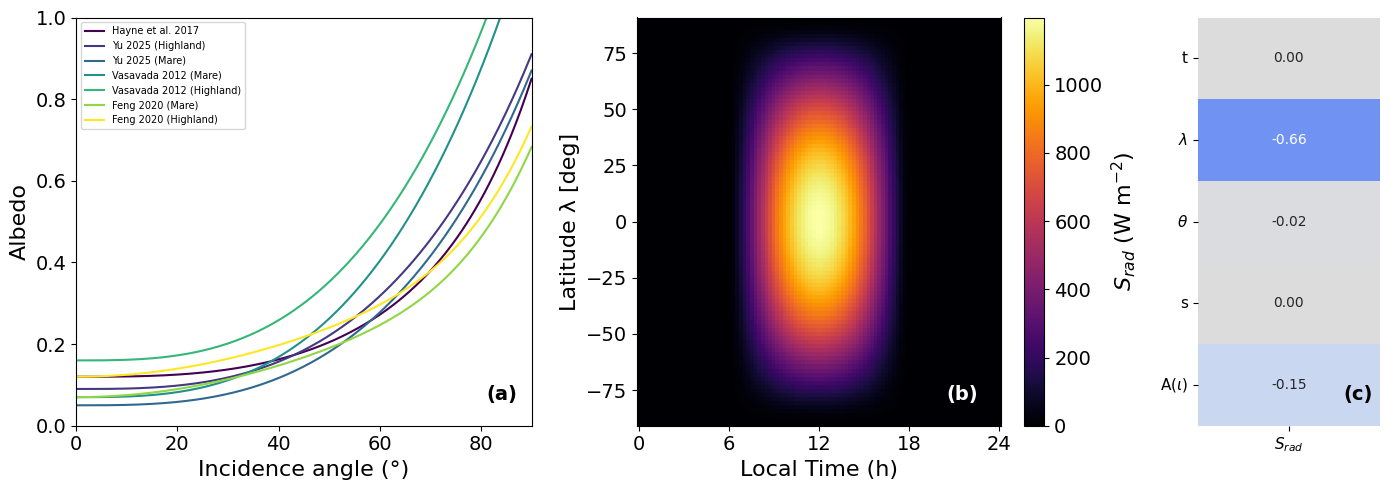

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================
# COMBINED FIGURE: ALBEDO + SOLAR FLUX + CORRELATION
# =====================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2.5, 2.5, 1]}
)


# =====================================================
# PANEL (a): ALBEDO MODELS
# =====================================================

ax = axes[0]

n = 7
colors = plt.cm.viridis(np.linspace(0, 1, n))

ax.plot(
    np.rad2deg(iota),
    albedo_hayne_2017(iota),
    label="Hayne et al. 2017",
    color=colors[0]
)

ax.plot(
    np.rad2deg(iota),
    albedo_yu_2025_highland(iota),
    label="Yu 2025 (Highland)",
    color=colors[1]
)

ax.plot(
    np.rad2deg(iota),
    albedo_yu_2025_mare(iota),
    label="Yu 2025 (Mare)",
    color=colors[2]
)

ax.plot(
    np.rad2deg(iota),
    albedo_vasavada_mare_2012(iota),
    label="Vasavada 2012 (Mare)",
    color=colors[3]
)

ax.plot(
    np.rad2deg(iota),
    albedo_vasavada_highland_2012(iota),
    label="Vasavada 2012 (Highland)",
    color=colors[4]
)

ax.plot(
    np.rad2deg(iota),
    albedo_feng_2020_mare(iota),
    label="Feng 2020 (Mare)",
    color=colors[5]
)

ax.plot(
    np.rad2deg(iota),
    albedo_feng_2020_highland(iota),
    label="Feng 2020 (Highland)",
    color=colors[6]
)


ax.set_xlabel("Incidence angle (°)", fontsize=16)
ax.set_ylabel("Albedo", fontsize=16)

ax.set_xlim(0, 90)
ax.set_ylim(0, 1)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=7,
    loc="upper left"
)


ax.text(
    0.9,
    0.1,
    "(a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
    color="black"
)



# =====================================================
# PANEL (b): INCOMING SOLAR RADIATION
# =====================================================

ax = axes[1]


im = ax.pcolormesh(
    T,
    L,
    Srad,
    shading="auto",
    cmap="inferno"
)


ax.set_xlabel(
    "Local Time (h)",
    fontsize=16
)

ax.set_ylabel(
    "Latitude λ [deg]",
    fontsize=16
)


ax.set_xticks(
    np.linspace(0, 24, 5)
)


ax.tick_params(
    axis="both",
    labelsize=14
)


cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    r"$S_{rad}$ (W m$^{-2}$)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=14
)


ax.text(
    0.85,
    0.1,
    "(b)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
    color="white"
)



# =====================================================
# PANEL (c): CORRELATION MATRIX
# =====================================================

ax = axes[2]


# Convert horizontal matrix into vertical matrix
corr_vertical = corr.T


sns.heatmap(
    corr_vertical,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cbar=False,
    ax=ax
)


ax.set_xlabel("")
ax.set_ylabel("")


ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=11
)

ax.tick_params(
    axis="x",
    rotation=0,
    labelsize=11
)


ax.text(
    0.8,
    0.1,
    "(c)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left",
    color="black"
)



# =====================================================
# FINAL FORMAT
# =====================================================

plt.tight_layout()


save_folder = os.path.join(
    root_folder,
    "Dry",
    "BC"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "boundary_conditions_combined.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Other plots

### Porosity, Cr, PFF

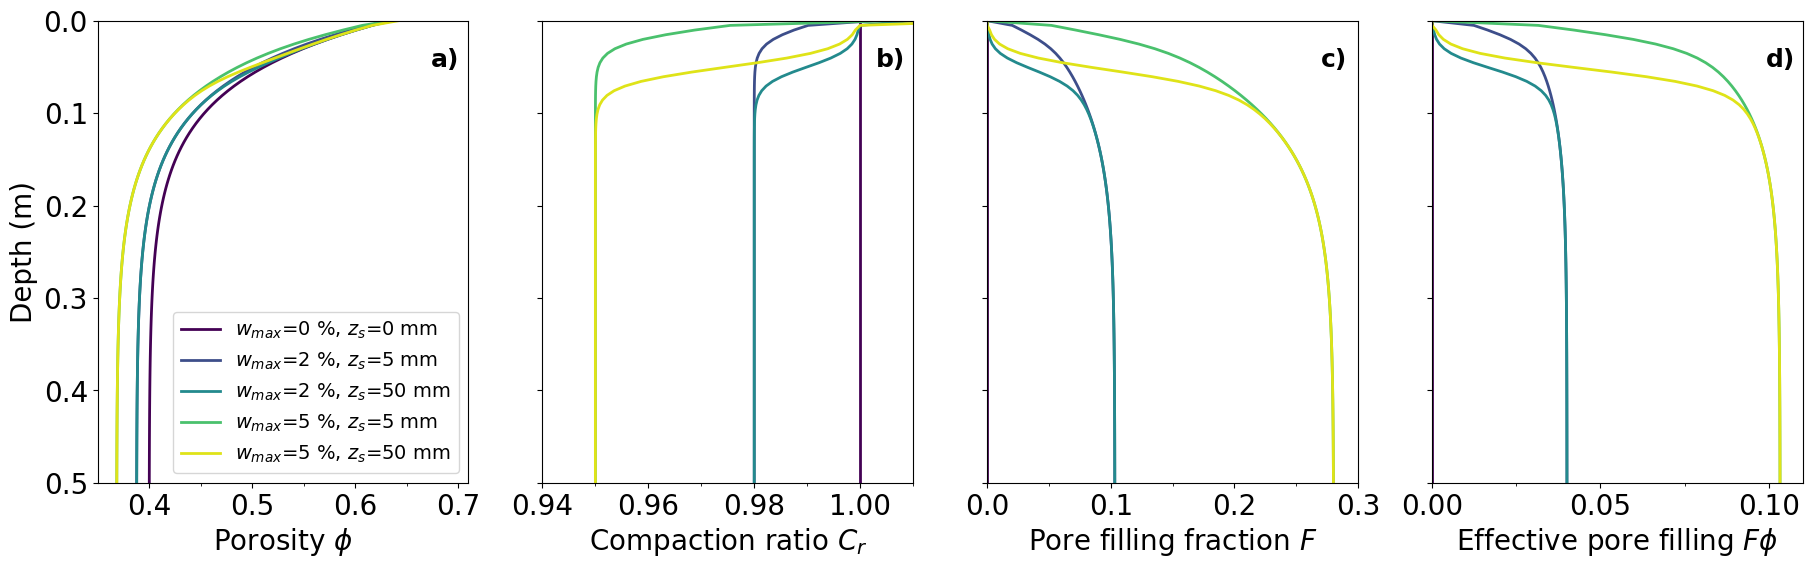

In [45]:
# -------------------------
# Depth grid
# -------------------------
z_rho = np.linspace(0, 0.5, 100)

# -------------------------
# CASES: (wt, z_start)
# -------------------------
wt_cases = [
    (0, 0.0),
    (2, 0.005),
    (2, 0.05),
    (5, 0.005),
    (5, 0.05)
]

colors2 = plt.cm.viridis(np.linspace(0, 0.95, len(wt_cases)))

# -------------------------
# Initialize
# -------------------------
phi_cases = {}
Cr_cases = {}
F_cases = {}
Fp_cases = {}

# -------------------------
# Compute profiles
# -------------------------
for i, (wt, z_start) in enumerate(wt_cases):

    rho = rho_effective_carlos_new2(
        z_rho,
        wt_max=wt,
        z_start=z_start)

    Cr = get_Cr(rho, z_rho)
    phi = porosity(rho)

    F = pore_filling_fraction(z_rho, Cr, phi)

    phi_cases[(wt, z_start)] = phi
    Cr_cases[(wt, z_start)] = Cr
    F_cases[(wt, z_start)] = F
    Fp_cases[(wt, z_start)] = F * phi

# =====================================================
# COMBINED FIGURE
# =====================================================

def label(wt, zs):
    return rf"$w_{{max}}$={wt} %, $z_s$={int(zs*1000)} mm"

fig, axes = plt.subplots(
    1,
    4,
    figsize=(22,6),
    sharey=True
)


# -------------------------
# Panel definitions
# -------------------------

plot_cases = [
    (
        phi_cases,
        r"Porosity $\phi$",
        "Porosity",
        (0.35, 0.71),
        np.arange(0.4, 0.71, 0.1),
        np.arange(0.4, 0.71, 0.05)
    ),
    
    (
        Cr_cases,
        r"Compaction ratio $C_r$",
        "Compaction ratio",
        (0.945, 1.005),
        np.arange(0.94, 1.01, 0.02),
        np.arange(0.94, 1.01, 0.01)
    ),

    (
        F_cases,
        r"Pore filling fraction $F$",
        "Pore filling fraction",
        (0, 0.3),
        np.arange(0, 0.31, 0.1),
        np.arange(0, 0.31, 0.05)
    ),

    (
        Fp_cases,
        r"Effective pore filling $F\phi$",
        "Effective pore filling",
        (0, 0.11),
        np.arange(0, 0.11, 0.05),
        np.arange(0, 0.11, 0.025)
    )
]


# -------------------------
# Plot
# -------------------------

for i, (ax, (data, xlabel, title, xlim, xticks, xminor)) in enumerate(
    zip(axes, plot_cases)
):

    for j, (wt, zs) in enumerate(wt_cases):

        if i == 0:
            ax.plot(
                data[(wt, zs)],
                z_rho,
                color=colors2[j],
                linewidth=2,
                label=label(wt, zs)
            )
        else:
            ax.plot(
                data[(wt, zs)],
                z_rho,
                color=colors2[j],
                linewidth=2
            )


    ax.set_xlabel(
        xlabel,
        fontsize=20
    )

    ax.set_xlim(
        xlim
    )

    ax.set_xticks(
        xticks
    )
    ax.set_xticks(
        xminor, minor = True, 
    )

    ax.tick_params(
        axis="x",
        labelsize=20
    )

    ax.set_ylim(
        0.5,
        0
    )

    ax.text(
        0.9,
        0.9,
        chr(97+i) + ")",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        color="black"
    )


# Shared y-axis label
axes[0].set_ylabel(
    "Depth (m)",
    fontsize=20
)

axes[0].tick_params(
    axis="y",
    labelsize=20
)


# Legend only in first subplot
axes[0].legend(
    fontsize=14,
    loc="lower right",
    frameon=True
)


# -------------------------
# Save
# -------------------------

save_folder = os.path.join(
    root_folder,
    "Icy",
    "Structure"
)

os.makedirs(
    save_folder,
    exist_ok=True
)


plt.savefig(
    os.path.join(
        save_folder,
        "structure_profiles_combined.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

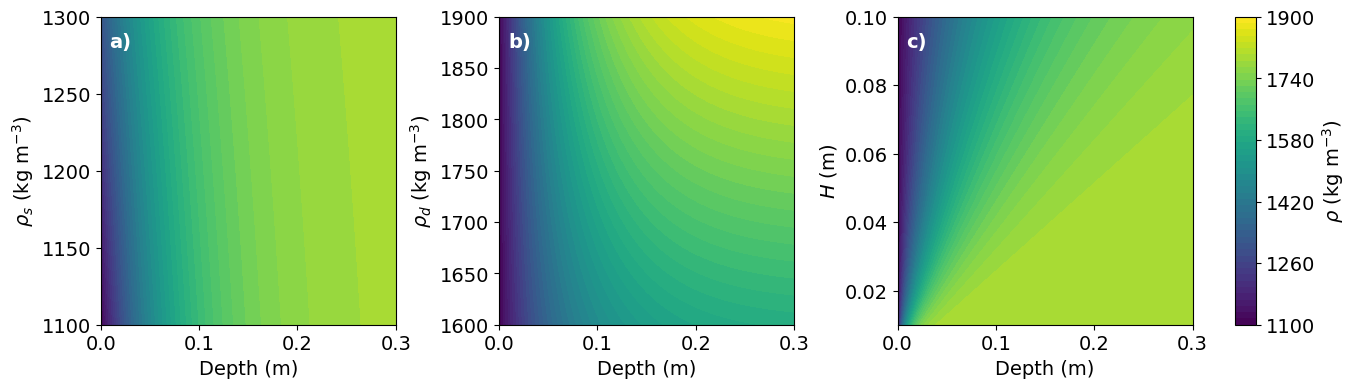

In [46]:
# ------------------------
# FONT SETTINGS
# -------------------------
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# -------------------------
# PARAMETERS
# -------------------------
z = np.linspace(0, 0.3, 200)

rho_s_vals = np.linspace(1100, 1300, 100)
rho_d_vals = np.linspace(1600, 1900, 100)
H_vals     = np.linspace(0.01, 0.10, 100)

# -------------------------
# Allocate arrays
# -------------------------
rho_s_map = np.empty((len(rho_s_vals), len(z)))
rho_d_map = np.empty((len(rho_d_vals), len(z)))
rho_H_map = np.empty((len(H_vals), len(z)))

# -------------------------
# Compute density profiles
# -------------------------
for i, rho_s in enumerate(rho_s_vals):
    rho_s_map[i] = rho_effective_carlos_new2(
        z, rho_s=rho_s
    )

for i, rho_d in enumerate(rho_d_vals):
    rho_d_map[i] = rho_effective_carlos_new2(
        z, rho_d=rho_d
    )

for i, H in enumerate(H_vals):
    rho_H_map[i] = rho_effective_carlos_new2(
        z, H=H
    )

# -------------------------
# COLOR SCALE
# -------------------------
CLIM_MIN = 1100
CLIM_MAX = 1900

levels = np.linspace(CLIM_MIN, CLIM_MAX, 50)
cbar_ticks = np.linspace(CLIM_MIN, CLIM_MAX, 6)

# -------------------------
# FIGURE
# -------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4)
)

# leave space for colorbar
plt.subplots_adjust(
    left=0.08,
    right=0.86,
    bottom=0.18,
    top=0.95,
    wspace=0.35
)

# -------------------------
# PANEL (a): rho_s
# -------------------------
im0 = axes[0].contourf(
    z,
    rho_s_vals,
    rho_s_map,
    levels=levels,
    cmap="viridis"
)

im0.set_clim(CLIM_MIN, CLIM_MAX)

axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel(r"$\rho_s$ (kg m$^{-3}$)")

axes[0].text(
    0.03,
    0.95,
    "a)",
    transform=axes[0].transAxes,
    color="white",
    fontsize=14,
    fontweight="bold",
    va="top"
)

# -------------------------
# PANEL (b): rho_d
# -------------------------
im1 = axes[1].contourf(
    z,
    rho_d_vals,
    rho_d_map,
    levels=levels,
    cmap="viridis"
)

im1.set_clim(CLIM_MIN, CLIM_MAX)

axes[1].set_xlabel("Depth (m)")
axes[1].set_ylabel(r"$\rho_d$ (kg m$^{-3}$)")

axes[1].text(
    0.03,
    0.95,
    "b)",
    transform=axes[1].transAxes,
    color="white",
    fontsize=14,
    fontweight="bold",
    va="top"
)

# -------------------------
# PANEL (c): H
# -------------------------
im2 = axes[2].contourf(
    z,
    H_vals,
    rho_H_map,
    levels=levels,
    cmap="viridis"
)

im2.set_clim(CLIM_MIN, CLIM_MAX)

axes[2].set_xlabel("Depth (m)")
axes[2].set_ylabel(r"$H$ (m)")

axes[2].text(
    0.03,
    0.95,
    "c)",
    transform=axes[2].transAxes,
    color="white",
    fontsize=14,
    fontweight="bold",
    va="top"
)

# -------------------------
# SINGLE COLORBAR
# -------------------------
cbar_ax = fig.add_axes(
    [0.89, 0.18, 0.015, 0.77]
)

cbar = fig.colorbar(
    im2,
    cax=cbar_ax,
    ticks=cbar_ticks
)

cbar.set_label(
    r"$\rho$ (kg m$^{-3}$)",
    fontsize=14
)

cbar.ax.tick_params(
    labelsize=14
)

# -------------------------
# SAVE
# -------------------------
save_folder = os.path.join(
    root_folder,
    "Dry",
    "Density"
)

os.makedirs(
    save_folder,
    exist_ok=True
)

plt.savefig(
    os.path.join(save_folder, "3D_combined.pdf"),
    bbox_inches="tight"
)

plt.show()